# STEP 1 — Data Collection & Preprocessing

In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import pandas_datareader.data as web
import matplotlib.pyplot as plt
import seaborn as sns 
from datetime import datetime
import requests
import warnings 
warnings.filterwarnings('ignore')


# 1.1 — Download S&P 500 tickers

In [7]:

def get_sp500_tickers():
    # URL de la page Wikipedia
    url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
    
    # Ajout d'un User-Agent pour imiter un navigateur
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36"
    }
    
    # Téléchargement de la page avec le User-Agent
    response = requests.get(url, headers=headers)
    
    # Analyse du contenu HTML pour extraire les tableaux
    tables = pd.read_html(response.text)
    
    # Le premier tableau contient la liste des entreprises du S&P 500
    sp500_table = tables[0]
    tickers = sp500_table['Symbol'].tolist()
    tickers = [t.replace('.', '-') for t in tickers]
    
    return tickers, sp500_table




In [10]:
tickers, sp500_table = get_sp500_tickers()
print(f"Number of S&P 500 stocks: {len(tickers)}")
print("First 10 tickers:", tickers[:10])
print("First 10 tickers:", len(tickers[:10]))
print("\n")
sp500_table.head()

Number of S&P 500 stocks: 503
First 10 tickers: ['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A']
First 10 tickers: 10




,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989


# 1.2 — Download price data


In [13]:
START = "2015-01-01"
END   = "2024-12-31"

# Download adjusted closing prices
# Use a subset for speed during development
SAMPLE = tickers[:100]  # Start with 100 stocks

raw_prices = yf.download(
    SAMPLE,
    start=START,
    end=END,
    auto_adjust=True,   # Adjusts for splits and dividends
    progress=False
)['Close']

print(f"Data shape: {raw_prices.shape}")
print(f"Date range: {raw_prices.index[0]} → {raw_prices.index[-1]}")
print(f"Missing values: {raw_prices.isna().sum().sum()}")

$AXON: possibly delisted; no price data found  (1d 2015-01-01 -> 2024-12-31)

1 Failed download:
['AXON']: possibly delisted; no price data found  (1d 2015-01-01 -> 2024-12-31)


Data shape: (2515, 100)
Date range: 2015-01-02 00:00:00 → 2024-12-30 00:00:00
Missing values: 7710


# 1.3 — Download Fama-French 5 Factors


In [14]:
def get_fama_french_factors():
    """
    Downloads Fama-French 5-factor model data from Ken French's website.
    Factors: Mkt-RF, SMB, HML, RMW, CMA, RF
    
    - Mkt-RF : Market excess return (market risk premium)
    - SMB    : Small Minus Big (size factor)
    - HML    : High Minus Low (value factor)
    - RMW    : Robust Minus Weak (profitability factor)
    - CMA    : Conservative Minus Aggressive (investment factor)
    - RF     : Risk-free rate
    """
    ff5 = web.DataReader(
        'F-F_Research_Data_5_Factors_2x3_daily',
        'famafrench',
        start=START,
        end=END
    )[0]
    ff5 = ff5 / 100  # Convert from % to decimal
    ff5.index = pd.to_datetime(ff5.index, format='%Y%m%d')
    return ff5

ff_factors = get_fama_french_factors()
print("\nFama-French Factors:")
print(ff_factors.head())


Fama-French Factors:
            Mkt-RF     SMB     HML     RMW     CMA   RF
Date                                                   
2015-01-02 -0.0012 -0.0056  0.0012 -0.0028  0.0015  0.0
2015-01-05 -0.0184  0.0025 -0.0067  0.0017 -0.0008  0.0
2015-01-06 -0.0103 -0.0079 -0.0029  0.0052  0.0006  0.0
2015-01-07  0.0119  0.0017 -0.0067  0.0026 -0.0017  0.0
2015-01-08  0.0181 -0.0010 -0.0029  0.0010 -0.0021  0.0


# 1.4 — Preprocessing


In [36]:
def preprocess_prices(prices, min_coverage=0.8):
    """
    Clean price data:
    - Remove stocks with too many missing values
    - Forward fill remaining gaps (max 5 days)
    - Drop stocks with no data at all
    
    Parameters:
    -----------
    prices       : DataFrame of closing prices
    min_coverage : minimum fraction of non-NaN values required
    """
    # Step 1: Drop stocks with insufficient data
    coverage = prices.notna().mean()
    prices = prices.loc[:, coverage >= min_coverage]
    print(f"Stocks after coverage filter: {prices.shape[1]}")
    
    # Step 2: Forward fill short gaps (max 5 business days)
    prices = prices.fillna(method='ffill', limit=5)
    
    # Step 3: Drop remaining NaN rows
    prices = prices.dropna(axis=1, how='any')
    print(f"Stocks after NaN removal: {prices.shape[1]}")
    
    return prices


In [37]:

prices = preprocess_prices(raw_prices)

print(prices.shape)

#pour la présence des valeurs Manquantes
print(prices.isna().sum().sum())  # doit afficher 0 , a clean dataset 

Stocks after coverage filter: 95
Stocks after NaN removal: 94
(2515, 94)
0


# Exemple de Visualisation du prix de AAPL

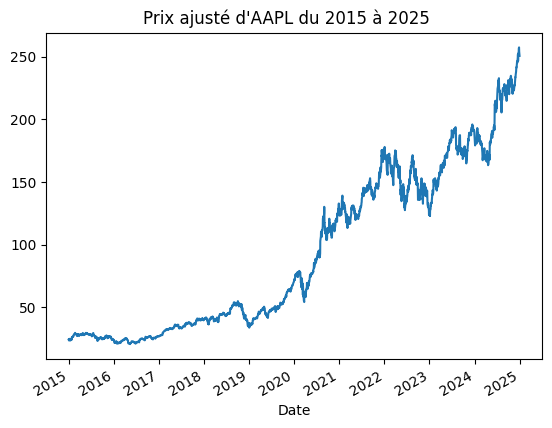

In [20]:

import matplotlib.pyplot as plt
prices['AAPL'].plot(title="Prix ajusté d'AAPL du 2015 à 2025   ")
plt.show()

# STEP 2 — Feature Engineering


# ─────────────────────────────────────────────────────────────
# TECHNICAL INDICATORS + FUNDAMENTAL FEATURES
# ─────────────────────────────────────────────────────────────



# ─── 2.1 Momentum Indicators ─────────────────────────────────


## RSI:Relative Strength Index

> *Indicateur de momentum*

- `avg_gain` : moyenne exponentielle des gains positifs sur `n` périodes
- `avg_loss` : moyenne exponentielle des pertes (valeurs absolues)

## Paramètres
- `prices` : `pd.Series` ou `pd.DataFrame` – prix de clôture ajustés
- `n` : `int`, par défaut 14 – période de calcul

## Retour
- `RSI` : même type que `prices` – valeurs entre 0 et 100

## Interprétation
| Valeur RSI | Signal |
|------------|--------|
| > 70       | Surachat – possible correction baissière |
| < 30       | Survente – possible rebond haussier |
| 30-70      | Zone neutre |



In [ ]:

def compute_RSI(prices, n=14):
    
    delta = prices.diff()
    gain  = delta.clip(lower=0)
    loss  = -delta.clip(upper=0)
    
    # Wilder smoothing (exponential with alpha = 1/n)
    avg_gain = gain.ewm(alpha=1/n, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/n, adjust=False).mean()
    
    RS  = avg_gain / avg_loss
    RSI = 100 - (100 / (1 + RS))
    return RSI




In [23]:
rsi = compute_RSI(prices, n=14)
print(rsi)

Ticker              A       AAPL       ABBV         ABT       ACGL        ACN  \
Date                                                                            
2015-01-02        NaN        NaN        NaN         NaN        NaN        NaN   
2015-01-05   0.000000   0.000000   0.000000  100.000000   0.000000   0.000000   
2015-01-06   0.000000   0.024966   0.000000   20.348414   2.777681   0.000000   
2015-01-07   5.063097   3.876200  14.552945   50.387440   9.832214   8.872742   
2015-01-08  15.595464  13.810933  18.012410   75.655931  26.955776  14.904278   
...               ...        ...        ...         ...        ...        ...   
2024-12-23  44.891678  73.085600  52.064337   47.153326  40.541707  49.319317   
2024-12-24  48.772533  75.750221  54.715145   49.410663  42.823645  51.353521   
2024-12-26  48.115710  76.452837  53.142587   51.917395  43.863726  50.438727   
2024-12-27  47.377690  67.626214  50.803517   50.439716  41.996789  47.229863   
2024-12-30  44.536458  60.22

## Moving Average Convergence Divergence

> *Indicateur de momentum*

## Paramètres
| Nom     | Type | Défaut | Description |
|---------|------|--------|-------------|
| `prices` | pd.Series / pd.DataFrame | – | Prix de clôture ajustés |
| `fast`   | int  | 12     | Période de l’EMA rapide |
| `slow`   | int  | 26     | Période de l’EMA lente |
| `signal` | int  | 9      | Période de la ligne de signal |

## Retour
| Variable    | Type | Description |
|-------------|------|-------------|
| `macd`      | same as input | Ligne MACD (différence des EMAs) |
| `sig_line`  | same as input | Ligne de signal (EMA du MACD) |
| `histogram` | same as input | Histogramme = MACD - Signal |

## Interprétation
- **MACD > Signal** → tendance haussière (signal d’achat)
- **MACD < Signal** → tendance baissière (signal de vente)
- **Histogramme croissant** → accélération de la tendance
- **Divergence** : si les prix créent un plus bas et le MACD un plus haut → signal haussier



In [25]:

def compute_MACD(prices, fast=12, slow=26, signal=9):
    
    ema_fast = prices.ewm(span=fast, adjust=False).mean()
    ema_slow = prices.ewm(span=slow, adjust=False).mean()
    
    macd      = ema_fast - ema_slow
    sig_line  = macd.ewm(span=signal, adjust=False).mean()
    histogram = macd - sig_line
    
    return macd, sig_line, histogram


## Exemple d’utilisation


In [ ]:
macd, signal, hist = compute_MACD(prices, fast=12, slow=26, signal=9)
print("MACD line:\n", macd.head())
print("\nSignal line:\n", signal.head())
print("\nHistogram:\n", hist.head())  ## En effet .head() affiche juste les 5 premiers 

MACD line:
 Ticker             A      AAPL      ABBV       ABT      ACGL       ACN  \
Date                                                                     
2015-01-02  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
2015-01-05 -0.055262 -0.054368 -0.062170  0.000641 -0.008850 -0.099169   
2015-01-06 -0.143010 -0.096168 -0.126213 -0.031491 -0.012396 -0.217387   
2015-01-07 -0.172319 -0.101519 -0.044595 -0.033277 -0.006435 -0.187206   
2015-01-08 -0.106789 -0.031477  0.054954  0.024561  0.024098 -0.072172   

Ticker          ADBE       ADI       ADM       ADP  ...       CPT       CRL  \
Date                                                ...                       
2015-01-02  0.000000  0.000000  0.000000  0.000000  ...  0.000000  0.000000   
2015-01-05 -0.028717 -0.064144 -0.103184 -0.003739  ... -0.015446  0.039886   
2015-01-06 -0.166559 -0.194956 -0.239601 -0.049594  ...  0.007125  0.092220   
2015-01-07 -0.226389 -0.259661 -0.301330 -0.040115  ...  0.131815  0.25581

# ROC – Rate of Change

> *Indicateur de momentum*

Le **Rate of Change (ROC)** mesure la variation en pourcentage du prix entre la période actuelle et une période passée. Il permet d’évaluer la vitesse et l’amplitude des mouvements de prix.

## Abréviation
**ROC** (Rate of Change)

## Formule mathématique

Soit :
- $P_t$ : prix de clôture à l’instant $t$
- $n$ : nombre de périodes de décalage (lookback)

$$
\text{ROC}_t = \frac{P_t - P_{t-n}}{P_{t-n}} \times 100
$$

Ou sous forme factorielle :

$$
\text{ROC}_t = \left( \frac{P_t}{P_{t-n}} - 1 \right) \times 100
$$


## Paramètres
| Nom | Type | Défaut | Description |
|-----|------|--------|-------------|
| `prices` | pd.Series / pd.DataFrame | – | Prix de clôture ajustés |
| `n` | int | 10 | Période de décalage (en jours ou séances) |

## Retour
- **ROC** : série ou DataFrame des mêmes dimensions que `prices`.  
  Valeurs positives = hausse sur \( n \) périodes, négatives = baisse.

## Interprétation
- **ROC > 0** → le prix est plus élevé qu’il y a \( n \) périodes (tendance haussière récente).
- **ROC < 0** → le prix est plus bas qu’il y a \( n \) périodes (tendance baissière récente).
- **Valeurs extrêmes** (très positives ou très négatives) peuvent signaler un surachat ou une survente.
- **Divergence** : prix créant un nouveau sommet mais ROC en baisse → affaiblissement du momentum.

## Exemple d’utilisation
```python
roc_10 = compute_ROC(prices, n=10)
roc_30 = compute_ROC(prices, n=30)

In [54]:

def compute_ROC(prices, n=10):
    return prices.pct_change(periods=n) * 100


# ─── 2.2 Volatility Indicators ───────────────────────────────




# Historical Volatility (HV)

> *Indicateur de Volatility*


La **volatilité historique** mesure la dispersion des rendements passés d’un actif sur une fenêtre glissante. Elle est annualisée pour être comparable entre différents horizons.

## Abréviation
**HV** (Historical Volatility)
## Formule mathématique

Soit :
- $r_t = \frac{P_t}{P_{t-1}} - 1$ : rendement simple à la date $t$
- $\sigma_{window}$ : écart‑type des rendements sur `window` périodes
- $T$ : nombre de périodes de trading par an (généralement 252 pour des données quotidiennes)

$$
\text{HV}_{\text{ann}} = \sigma_{window} \times \sqrt{T}
$$

En notation détaillée :

$$
\text{HV}_t = \sqrt{252} \times \sqrt{ \frac{1}{n-1} \sum_{i=t-n+1}^{t} (r_i - \bar{r})^2 }
$$

## Paramètres
| Nom | Type | Défaut | Description |
|-----|------|--------|-------------|
| `returns` | pd.Series / pd.DataFrame | – | Rendements simples (ex: `prices.pct_change()`) |
| `window` | int | 20 | Taille de la fenêtre glissante (en jours) |

## Retour
- **HV** : série ou DataFrame des mêmes dimensions que `returns`.  
  Valeur annualisée, exprimée en unité de rendement (ex: 0.25 = 25% de volatilité annualisée).

## Interprétation
- Une **HV élevée** indique que l’actif a connu de fortes fluctuations récentes (risque élevé).
- Une **HV faible** suggère une période de calme (risque faible).
- Comparée à la volatilité implicite (VIX pour le S&P 500), elle donne une idée du **paradoxe de la volatilité**.
- Valeurs typiques pour une action : 15% – 40% annualisé.



In [28]:


def compute_historical_volatility(returns, window=20):
    
    return returns.rolling(window).std() * np.sqrt(252)



## Exemple d’utilisation


In [30]:
returns = prices.pct_change()
hv_20 = compute_historical_volatility(returns, window=20)
hv_60 = compute_historical_volatility(returns, window=60)
print(hv_20),print(hv_60)

Ticker             A      AAPL      ABBV       ABT      ACGL       ACN  \
Date                                                                     
2015-01-02       NaN       NaN       NaN       NaN       NaN       NaN   
2015-01-05       NaN       NaN       NaN       NaN       NaN       NaN   
2015-01-06       NaN       NaN       NaN       NaN       NaN       NaN   
2015-01-07       NaN       NaN       NaN       NaN       NaN       NaN   
2015-01-08       NaN       NaN       NaN       NaN       NaN       NaN   
...              ...       ...       ...       ...       ...       ...   
2024-12-23  0.217877  0.141174  0.207340  0.119810  0.196859  0.326664   
2024-12-24  0.220718  0.140135  0.209547  0.120247  0.198391  0.326856   
2024-12-26  0.220855  0.139406  0.193104  0.122034  0.198070  0.326535   
2024-12-27  0.195701  0.152640  0.189572  0.116772  0.196451  0.329040   
2024-12-30  0.197453  0.162911  0.192122  0.132052  0.195866  0.330792   

Ticker          ADBE       ADI       

(None, None)

# ATR – Average True Range
> * Indicateur de Volatility inventé par
> *J. Welles Wilder Jr., 1978*

L’**Average True Range (ATR)** mesure la **volatilité absolue** d’un actif, indépendamment de la direction du prix. Il est largement utilisé pour le dimensionnement des positions et le placement des stops.


## Formules mathématiques

### True Range (TR) – intervalle vrai
Le TR est la plus grande des trois différences suivantes :
- $H - L$   (plus haut – plus bas de la séance)
- $|H - C_{t-1}|$   (plus haut – clôture précédente en valeur absolue)
- $|L - C_{t-1}|$   (plus bas – clôture précédente en valeur absolue)

Soit :
$$
TR_t = \max( H_t - L_t , |H_t - C_{t-1}| , |L_t - C_{t-1}| )
$$

### ATR – lissage exponentiel de Wilder
Wilder utilise un lissage exponentiel avec $\alpha = \frac{1}{n}$ (sans ajustement) :
$$
ATR_t = ATR_{t-1} + \frac{1}{n} (TR_t - ATR_{t-1})
$$

On initialise souvent $ATR_n$ = moyenne simple des TR sur les $n$ premières périodes.



## Paramètres
| Nom | Type | Défaut | Description |
|-----|------|--------|-------------|
| `high` | pd.Series | – | Prix le plus haut de la séance |
| `low`  | pd.Series | – | Prix le plus bas de la séance |
| `close`| pd.Series | – | Prix de clôture |
| `n`    | int | 14 | Période de l’ATR (Wilder recommande 14) |

## Retour
- **ATR** : série (même index que `high`).  
  Valeur exprimée dans l’**unité monétaire** du titre (dollars, euros, etc.).  
  Plus l’ATR est élevé, plus la volatilité absolue est forte.

## Interprétation
- L’ATR ne donne **pas de signal directionnel** (hausse/baisse), seulement l’amplitude des mouvements.
- Un ATR croissant indique une **volatilité qui augmente** (possible retournement ou accélération).
- Utilisation pratique :
  - **Stop loss** : on place un stop à `k * ATR` en dessous du prix (ex: 2 × ATR).
  - **Dimensionnement** : risque par trade = `taille_position × ATR`. On ajuste la position pour respecter un risque maximum (ex: 1% du capital).
- Comparé à la volatilité historique (qui est relative), l’ATR est absolu.



In [32]:

def compute_ATR(high, low, close, n=14):
    
    tr1 = high - low
    tr2 = (high - close.shift(1)).abs()
    tr3 = (low  - close.shift(1)).abs()
    
    TR  = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    ATR = TR.ewm(alpha=1/n, adjust=False).mean()
    return ATR


## Exemple d'utilisation

In [39]:
# Approximation grossière (ne remplace pas l'ATR)
compute_ATR = prices.rolling(14).apply(lambda x: x.max() - x.min(), raw=True)
print(compute_ATR)

Ticker              A       AAPL      ABBV       ABT      ACGL        ACN  \
Date                                                                        
2015-01-02        NaN        NaN       NaN       NaN       NaN        NaN   
2015-01-05        NaN        NaN       NaN       NaN       NaN        NaN   
2015-01-06        NaN        NaN       NaN       NaN       NaN        NaN   
2015-01-07        NaN        NaN       NaN       NaN       NaN        NaN   
2015-01-08        NaN        NaN       NaN       NaN       NaN        NaN   
...               ...        ...       ...       ...       ...        ...   
2024-12-23  10.857346  12.351135  6.530731  3.920296  9.779999  24.000916   
2024-12-24  10.857346  15.262527  8.061218  3.561256  9.779999  24.000916   
2024-12-26  10.857346  16.077316  8.061218  3.561256  9.120003  24.000916   
2024-12-27  10.857346  12.450455  8.061218  3.464218  7.190002  24.000916   
2024-12-30   8.812332  12.450455  8.061218  3.464218  5.360001  24.000916   

# Bollinger Bands


> * Indicateur du Volatility
> *John Bollinger, 1980s*

Les **bandes de Bollinger** sont un indicateur de volatilité relative qui encadre le prix par deux bandes placées à `k` écarts‑types d’une moyenne mobile simple. Elles permettent de détecter les surachats / surventes et les phases de compression de volatilité (squeeze).

## Abréviation
**BB** (Bollinger Bands)

## Formules mathématiques

Soit :
- $P_t$ : prix de clôture à l’instant $t$
- $n$ : période de la moyenne mobile (défaut 20)
- $k$ : nombre d’écarts‑types (défaut 2)

### Bande médiane (SMA)
$$
\text{SMA}_t = \frac{1}{n} \sum_{i=0}^{n-1} P_{t-i}
$$

### Bande supérieure et inférieure
$$
\text{BB\_upper}_t = \text{SMA}_t + k \times \sigma_t
$$

$$
\text{BB\_lower}_t = \text{SMA}_t - k \times \sigma_t
$$

où $\sigma_t$ est l’écart‑type des prix sur la même fenêtre $n$.

### %B (position relative dans la bande)
$$
\%B_t = \frac{P_t - \text{BB\_lower}_t}{\text{BB\_upper}_t - \text{BB\_lower}_t}
$$

### Bandwidth (largeur relative)
$$
\text{Bandwidth}_t = \frac{\text{BB\_upper}_t - \text{BB\_lower}_t}{\text{SMA}_t}
$$


In [40]:

def compute_bollinger_bands(prices, n=20, k=2):

    sma      = prices.rolling(n).mean()
    sigma    = prices.rolling(n).std()
    
    bb_upper = sma + k * sigma
    bb_lower = sma - k * sigma
    pct_b    = (prices - bb_lower) / (bb_upper - bb_lower)
    bandwidth = (bb_upper - bb_lower) / sma
    
    return bb_upper, bb_lower, pct_b, bandwidth




# ─── 2.3 Trend Indicators ────────────────────────────────────


# ADX – Average Directional Index


> *Indicateur de Trend inventé par
> *J. Welles Wilder Jr., 1978*

L’**ADX** (Average Directional Index) mesure la **force de la tendance** (haussière ou baissière) sans en indiquer la direction. Il est accompagné des lignes +DI et -DI qui signalent la direction dominante.


## Formules mathématiques

### 1. True Range (TR)
Comme pour l’ATR :  
TR = max(H - L, |H - C_{t-1}|, |L - C_{t-1}|)

### 2. Mouvements directionnels (+DM, -DM)
- **+DM** = max(H_t - H_{t-1}, 0)   (si > |-DM|, sinon 0)
- **-DM** = max(L_{t-1} - L_t, 0)   (si > |+DM|, sinon 0)

### 3. Indicateurs directionnels (+DI, -DI)
- **+DI** = 100 × EMA(+DM) / ATR
- **-DI** = 100 × EMA(-DM) / ATR  
  (Lissage exponentiel selon Wilder : alpha = 1/n)

### 4. Directional Index (DX) et ADX
- **DX** = 100 × |+DI – (-DI)| / (+DI + (-DI))
- **ADX** = EMA(DX) sur la même période n

## Paramètres
| Nom | Type | Défaut | Description |
|-----|------|--------|-------------|
| `high` | pd.Series | – | Prix les plus hauts |
| `low`  | pd.Series | – | Prix les plus bas |
| `close`| pd.Series | – | Prix de clôture |
| `n`    | int | 14 | Période de calcul (recommandée par Wilder) |

## Retour
| Variable | Description |
|----------|-------------|
| `adx`    | Force de la tendance (0-100) |
| `plus_di`| Indicateur directionnel haussier |
| `minus_di`| Indicateur directionnel baissier |

## Interprétation
| ADX | Signification |
|-----|---------------|
| > 25 | Tendance forte (haussière ou baissière) |
| 20–25 | Tendance émergente |
| < 20 | Pas de tendance (marché en range) |

**Directions :**
- +DI > -DI → pression haussière
- -DI > +DI → pression baissière
- Croisements des DI signalent des changements de tendance.



In [42]:

def compute_ADX(high, low, close, n=14):
    
    atr = compute_ATR(high, low, close, n)
    
    plus_dm  = (high.diff()).clip(lower=0)
    minus_dm = (-low.diff()).clip(lower=0)
    
    # Zero out when the other direction is stronger
    mask = plus_dm >= minus_dm
    plus_dm  = plus_dm.where(mask, 0)
    minus_dm = minus_dm.where(~mask, 0)
    
    plus_di  = 100 * plus_dm.ewm(alpha=1/n,  adjust=False).mean() / atr
    minus_di = 100 * minus_dm.ewm(alpha=1/n, adjust=False).mean() / atr
    
    dx  = 100 * (plus_di - minus_di).abs() / (plus_di + minus_di)
    adx = dx.ewm(alpha=1/n, adjust=False).mean()
    
    return adx, plus_di, minus_di




# Moving Averages – SMA & EMA
> *Indicateur de Trend *

Les **moyennes mobiles** lissent les données de prix pour identifier la direction de la tendance. Elles sont parmi les indicateurs les plus utilisés en analyse technique.

## Abréviations
- **SMA** : Simple Moving Average (moyenne mobile simple)
- **EMA** : Exponential Moving Average (moyenne mobile exponentielle)

## Formules mathématiques

### Moyenne mobile simple (SMA)

$$ \text{SMA}_t(n) = \frac{1}{n} \sum_{i=0}^{n-1} P_{t-i}$$


### Moyenne mobile exponentielle (EMA)

$$ \text{EMA}_t = P_t \cdot \alpha + \text{EMA}_{t-1} \cdot (1 - \alpha) $$

avec facteur de lissage \ $$ ( \alpha = \frac{2}{n+1} \ ) $$  

## Paramètres
| Nom | Type | Défaut | Description |
|-----|------|--------|-------------|
| `prices` | pd.Series / pd.DataFrame | – | Prix de clôture ajustés |

La fonction calcule automatiquement :
- SMA sur 20, 50 et 200 périodes
- EMA sur 20 et 50 périodes

## Retour
Un dictionnaire contenant 5 séries (ou DataFrames) :

| Clé | Description |
|-----|-------------|
| `'SMA_20'` | Moyenne mobile simple sur 20 périodes |
| `'SMA_50'` | Moyenne mobile simple sur 50 périodes |
| `'SMA_200'` | Moyenne mobile simple sur 200 périodes |
| `'EMA_20'` | Moyenne mobile exponentielle sur 20 périodes |
| `'EMA_50'` | Moyenne mobile exponentielle sur 50 périodes |

## Interprétation

| Signal | Condition |
|--------|-----------|
| **Golden Cross** (haussier) | SMA 50 > SMA 200 |
| **Death Cross** (baissier) | SMA 50 < SMA 200 |
| Prix au‑dessus de la SMA 200 | Tendance primaire haussière |
| Prix en dessous de la SMA 200 | Tendance primaire baissière |
| EMA 20 > SMA 50 | Dynamique haussière à court terme |

L’EMA réagit plus rapidement aux changements de prix que la SMA équivalente.



In [43]:

def compute_moving_averages(prices):
    return {
        'SMA_20' : prices.rolling(20).mean(),
        'SMA_50' : prices.rolling(50).mean(),
        'SMA_200': prices.rolling(200).mean(),
        'EMA_20' : prices.ewm(span=20, adjust=False).mean(),
        'EMA_50' : prices.ewm(span=50, adjust=False).mean(),
    }




### Exemple d’utilisation


# ─── 2.4 Correlation Feature ─────────────────────────────────


# Rolling Correlation

> *Corrélation glissante entre deux séries temporelles*

La **corrélation glissante** mesure la relation linéaire entre deux séries de prix ou de rendements sur une fenêtre mobile de taille `n`.  
Elle permet de détecter si deux actifs évoluent de manière similaire ou divergente au cours du temps.

## Formule mathématique

Soit deux séries de rendements $X_t$ et $Y_t$, et une fenêtre de taille $n$ :

$$
\rho_t = \frac{\text{Cov}(X_{t-n+1:t}, Y_{t-n+1:t})}{\sigma_X \cdot \sigma_Y}
$$

où :
- $\text{Cov}(X, Y)$ = covariance des deux séries sur la fenêtre
- $\sigma_X, \sigma_Y$ = écarts-types respectifs sur la fenêtre
- $\rho_t$ = coefficient de corrélation de Pearson à l’instant $t$

## Paramètres
| Nom | Type | Défaut | Description |
|-----|------|--------|-------------|
| `series1` | pd.Series | – | Première série (ex. rendements d’un actif) |
| `series2` | pd.Series | – | Deuxième série |
| `window` | int | 60 | Taille de la fenêtre mobile |

## Retour
| Variable | Type | Description |
|----------|------|-------------|
| `rolling_corr` | pd.Series | Corrélation glissante entre les deux séries |



In [ ]:
def compute_rolling_correlation(returns, benchmark, window=60):
    
    corr = returns.rolling(window).corr(benchmark)
    return corr




# ─── 2.5 Liquidity Indicators ────────────────────────────────


# Liquidity Features

> *Indicateurs de liquidité d’un actif financier*

La **liquidité** mesure la capacité d’un actif à être échangé rapidement sans provoquer de variation significative de son prix.  
Cette fonction calcule deux indicateurs essentiels : **Amihud Illiquidity** et **Dollar Volume**.

## Formules mathématiques

Soit :
- $P_t$ : prix de clôture à l’instant $t$
- $V_t$ : volume échangé à l’instant $t$
- $r_t = \frac{P_t}{P_{t-1}} - 1$ : rendement simple

### Amihud Illiquidity
$$
ILLIQ_t = \frac{|r_t|}{P_t \times V_t} \times 10^6
$$

- Plus la valeur est élevée, plus l’actif est **illiquide** (petits volumes entraînent de grands mouvements de prix).

### Dollar Volume
$$
DV_t = P_t \times V_t
$$

- Mesure la valeur totale échangée en dollars (proxy de profondeur de marché).

## Paramètres
| Nom | Type | Description |
|-----|------|-------------|
| `prices` | pd.Series | Série des prix de clôture |
| `volume` | pd.Series | Série des volumes échangés |

## Retour
| Variable | Type | Description |
|----------|------|-------------|
| `amihud` | pd.Series | Indicateur Amihud Illiquidity (impact prix/volume) |
| `dollar_volume` | pd.Series | Valeur totale échangée (prix × volume) |

## Interprétation
- **Amihud élevé** → faible liquidité, risque accru de slippage.  
- **Dollar Volume élevé** → marché profond et actif.  
- Ces mesures sont utiles pour filtrer les actifs tradables et éviter ceux trop illiquides.


In [48]:
def compute_liquidity_features(prices, volume):
    
    returns      = prices.pct_change().abs()
    dollar_volume = prices * volume
    amihud       = returns / dollar_volume * 1e6  # scaled
    
    return amihud, dollar_volume


# ─── 2.6 Build Complete Feature Matrix ───────────────────────


### ÉTAPE 1 — Définir simple_ret AVANT tout


In [49]:


# simple_ret doit avoir le MÊME index que prices (pas de dropna)
simple_ret = prices.pct_change()   # ← pas de .dropna() ici

print(f"prices     : {prices.shape}")
print(f"simple_ret : {simple_ret.shape}")
assert prices.shape == simple_ret.shape, "❌ Index mismatch!"
print("✅ Index alignés")


prices     : (2515, 94)
simple_ret : (2515, 94)
✅ Index alignés


# Feature Matrix Construction

> *Assemblage des indicateurs techniques et financiers dans une matrice de caractéristiques*

La fonction **`build_feature_matrix(prices, returns)`** construit un ensemble de **features** (indicateurs) pour chaque actif et chaque date, afin d’alimenter un modèle de Machine Learning ou une analyse quantitative.

## Vérification préalable
- Les index de `prices` et `returns` doivent être identiques.  
- Si ce n’est pas le cas, une erreur est levée avec un message explicite.  
- ⚠️ Utiliser `simple_ret = prices.pct_change()` sans `.dropna()` pour garantir la cohérence des index.

## Catégories de Features

### Momentum
- **RSI_14** : Relative Strength Index sur 14 périodes  
- **MACD, MACD_signal, MACD_hist** : Moving Average Convergence Divergence  
- **ROC_10, ROC_30** : Rate of Change sur 10 et 30 périodes

### Volatilité
- **HV_20, HV_60** : Historical Volatility sur 20 et 60 jours  
- **BB_pctB** : Position relative dans les bandes de Bollinger  
- **BB_bandwidth** : Largeur relative des bandes de Bollinger  
- **vol_ratio** : Ratio HV_20 / HV_60 (volatilité court terme vs long terme)

### Tendance
- **Price_SMA50_ratio** : Prix / SMA50  
- **SMA50_SMA200_ratio** : SMA50 / SMA200 (indicateur de croisement de moyennes mobiles)

### Rendements passés
- **ret_1d** : rendement quotidien  
- **ret_5d** : rendement sur 5 jours  
- **ret_21d** : rendement sur 21 jours

## Paramètres
| Nom | Type | Description |
|-----|------|-------------|
| `prices` | pd.DataFrame | Prix de clôture des actifs |
| `returns` | pd.DataFrame | Rendements simples (mêmes index que `prices`) |

## Retour
| Variable | Type | Description |
|----------|------|-------------|
| `features` | dict | Dictionnaire de séries/features par indicateur |

## Contrôles intégrés
- Affiche le nombre total de features calculés.  
- Vérifie et affiche le pourcentage de valeurs manquantes (NaN) pour chaque feature.  

## Interprétation
- La matrice de features est utilisée pour entraîner des modèles de **Machine Learning en trading**.  
- Chaque catégorie (momentum, volatilité, tendance, rendement) capture une dimension différente du comportement des actifs.  
- Le contrôle des NaN permet de s’assurer de la qualité des données avant l’agrégation finale.


In [ ]:

def build_feature_matrix(prices, returns):
    
    features = {}

    # ── Vérification préalable ────────────────────────────────
    assert prices.index.equals(returns.index), (
        f"❌ Index mismatch: prices={prices.shape}, returns={returns.shape}\n"
        f"   Utilise simple_ret = prices.pct_change() sans .dropna()"
    )

    # ── Momentum ─────────────────────────────────────────────
    features['RSI_14']       = compute_RSI(prices, 14)
    macd, sig, hist          = compute_MACD(prices)
    features['MACD']         = macd
    features['MACD_signal']  = sig
    features['MACD_hist']    = hist
    features['ROC_10']       = compute_ROC(prices, 10)
    features['ROC_30']       = compute_ROC(prices, 30)

    # ── Volatility ───────────────────────────────────────────
    features['HV_20']        = compute_historical_volatility(returns, 20)
    features['HV_60']        = compute_historical_volatility(returns, 60)
    bb_up, bb_lo, pctb, bw   = compute_bollinger_bands(prices)
    features['BB_pctB']      = pctb
    features['BB_bandwidth'] = bw

    # ── Trend ────────────────────────────────────────────────
    mas = compute_moving_averages(prices)
    features['Price_SMA50_ratio']  = prices / mas['SMA_50']
    features['SMA50_SMA200_ratio'] = mas['SMA_50'] / mas['SMA_200']

    # ── Past Returns ─────────────────────────────────────────
    features['ret_1d']  = returns
    features['ret_5d']  = prices.pct_change(5)
    features['ret_21d'] = prices.pct_change(21)

    # ── Volatility Ratio ─────────────────────────────────────
    features['vol_ratio'] = features['HV_20'] / features['HV_60']

    print(f"✅ Features computed : {len(features)}")
    for name, feat in features.items():
        nan_pct = feat.isna().mean().mean() * 100
        print(f"   {name:<22} shape={feat.shape}  NaN={nan_pct:.1f}%")

    return features


In [71]:

features_dict = build_feature_matrix(prices, simple_ret)


✅ Features computed : 16
   RSI_14                 shape=(2515, 94)  NaN=0.0%
   MACD                   shape=(2515, 94)  NaN=0.0%
   MACD_signal            shape=(2515, 94)  NaN=0.0%
   MACD_hist              shape=(2515, 94)  NaN=0.0%
   ROC_10                 shape=(2515, 94)  NaN=0.4%
   ROC_30                 shape=(2515, 94)  NaN=1.2%
   HV_20                  shape=(2515, 94)  NaN=0.8%
   HV_60                  shape=(2515, 94)  NaN=2.4%
   BB_pctB                shape=(2515, 94)  NaN=0.8%
   BB_bandwidth           shape=(2515, 94)  NaN=0.8%
   Price_SMA50_ratio      shape=(2515, 94)  NaN=1.9%
   SMA50_SMA200_ratio     shape=(2515, 94)  NaN=7.9%
   ret_1d                 shape=(2515, 94)  NaN=0.0%
   ret_5d                 shape=(2515, 94)  NaN=0.2%
   ret_21d                shape=(2515, 94)  NaN=0.8%
   vol_ratio              shape=(2515, 94)  NaN=2.4%


#### — Stack en Panel DataFrame


In [64]:

feature_panel = pd.concat(features_dict, axis=1)
feature_panel.columns.names = ['feature', 'ticker']

print(f"\nFeature panel shape : {feature_panel.shape}")
print()
print(f"Index range         : {feature_panel.index[0].date()} → {feature_panel.index[-1].date()}")
print(f"NaN total           : {feature_panel.isna().sum().sum():,}")
print(f"NaN (%)             : {feature_panel.isna().mean().mean()*100:.1f}%")
print()
print(feature_panel.head(3))


Feature panel shape : (2515, 1504)

Index range         : 2015-01-02 → 2024-12-30
NaN total           : 46,605
NaN (%)             : 1.2%

feature    RSI_14                                                           \
ticker          A      AAPL ABBV         ABT      ACGL  ACN ADBE  ADI  ADM   
Date                                                                         
2015-01-02    NaN       NaN  NaN         NaN       NaN  NaN  NaN  NaN  NaN   
2015-01-05    0.0  0.000000  0.0  100.000000  0.000000  0.0  0.0  0.0  0.0   
2015-01-06    0.0  0.024966  0.0   20.348414  2.777681  0.0  0.0  0.0  0.0   

feature          ... vol_ratio                                           
ticker      ADP  ...       CPT CRL GOOG GOOGL LNT MMM  MO SCHW   T TECH  
Date             ...                                                     
2015-01-02  NaN  ...       NaN NaN  NaN   NaN NaN NaN NaN  NaN NaN  NaN  
2015-01-05  0.0  ...       NaN NaN  NaN   NaN NaN NaN NaN  NaN NaN  NaN  
2015-01-06  0.0  ... 

### Sauvgarder seulment pour Visualisation 

In [74]:
# Sauvegarde à la racine du projet
# index=True est obligatoire car l'index contient les dates historiques
feature_panel.to_csv("feature_panel.csv", index=True)

print("✅ Le fichier 'feature_panel.csv' a été enregistré avec succès à la racine !")

✅ Le fichier 'feature_panel.csv' a été enregistré avec succès à la racine !


# ─────────────────────────────────────────────────────────────
# STEP 3 — ML Models
# ─────────────────────────────────────────────────────────────


# 🤖 Guide des Modèles et Outils de Machine Learning

Ce notebook utilise un ensemble d'outils de la bibliothèque `scikit-learn` et `xgboost` pour le prétraitement des données, le clustering, la classification, la régression et l'évaluation des performances, particulièrement adapté aux données temporelles.

---

## 1. Prétraitement et Mise à l'échelle (Preprocessing)
Ces outils permettent de normaliser les fonctionnalités numériques pour que les modèles fonctionnent de manière optimale.

* **`StandardScaler`** : Centre les données (moyenne = 0) et les réduit (variance = 1). Très sensible aux valeurs aberrantes (outliers).
* **`RobustScaler`** : Supprime la médiane et met à l'échelle les données selon la plage interquartile (IQR). **Idéal en présence de valeurs aberrantes**.

## 2. Apprentissage Non Supervisé (Clustering)
* **`KMeans`** : Algorithme de clustering qui regroupe les données en *k* groupes distincts basés sur la distance géométrique (euclidienne) par rapport aux centroïdes.

## 3. Modèles de Classification et Régression
Une sélection de modèles puissants pour les tâches supervisées :

### 🌲 Modèles d'Ensemble & Boosting
* **`RandomForestClassifier`** : Forêt d'arbres décisionnels. Excellent modèle de base, robuste au surapprentissage grâce au bagging.
* **`GradientBoostingClassifier`** : Construit des arbres de décision de manière séquentielle, chaque arbre corrigeant les erreurs du précédent.
* **`xgb.XGBClassifier` / `XGBRegressor`** : Implémentation ultra-optimisée du Gradient Boosting. Très rapide et performant en compétition.

### 📈 Modèles Linéaires
* **`LogisticRegression`** : Modèle linéaire classique utilisé pour la classification binaire ou multiclasse.
* **`Lasso`** : Régression linéaire avec régularisation L1. Utile pour la sélection de variables (force certains coefficients à être exactement égaux à 0).

## 4. Validation et Évaluation

### ⏱️ Validation Croisée Temporelle
* **`TimeSeriesSplit`** : Une variante de la validation croisée K-Fold adaptée aux **séries temporelles**. Elle garantit qu'on n'utilise jamais le futur pour prédire le passé (respect de l'ordre chronologique).

### 📊 Métriques de Performance
* **`classification_report`** : Génère un bilan textuel des principales métriques (Précision, Rappel, F1-score) par classe.
* **`confusion_matrix`** : Matrice de confusion pour visualiser les vrais/faux positifs et vrais/faux négatifs.
* **`roc_auc_score`** : Calcule l'aire sous la courbe ROC. Évalue la capacité du modèle à séparer les classes, indépendamment du seuil de décision.

## 5. Industrialisation (Pipeline)
* **`Pipeline`** : Permet d'enchaîner proprement les étapes de transformation (ex: `StandardScaler`) et l'estimateur final (ex: `LogisticRegression`) pour éviter les fuites de données (*data leakage*).



## Importation des modéles utilisées

In [65]:
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import (RandomForestClassifier,
                              GradientBoostingClassifier)
from sklearn.linear_model import LogisticRegression, Lasso
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             roc_auc_score)
from sklearn.pipeline import Pipeline
import xgboost as xgb


## 3.1 — Prepare ML Dataset (Cross-sectional)

# 📊 Préparation du Dataset : `prepare_ml_dataset`

## 🎯 1. Utilité de la fonction
Cette fonction est le pont entre l'analyse financière brute et le Machine Learning. Son but est de **construire un jeu de données supervisé** pour un problème de **classification binaire**. 

Elle répond à la question : *« En me basant sur les caractéristiques (features) d'une action à l'instant $t$, est-ce qu'elle fera partie des meilleures performances dans les $N$ prochains jours ? »*

### 💡 Pourquoi cette approche est intelligente (Approche Cross-Sectionnelle) :
Plutôt que de prédire le rendement exact d'une action (très difficile et bruité), cette fonction utilise un **classement relatif (cross-sectional)** à une date donnée. 
* **Réduction du bruit :** En supprimant les **40% du milieu** (les actions neutres), on force le modèle de Machine Learning à se concentrer uniquement sur les signaux clairs : les grands gagnants et les grands perdants.

---



#### 
    Build supervised learning dataset:
    
    X = feature values at time t
    y = LABEL at time t (will the stock outperform in next 21 days?)
    
    Label definition:
    -----------------
    Compute cross-sectional rank of forward returns.
    Label = 1 if stock is in top 30% (BUY signal)
    Label = 0 if stock is in bottom 30% (SELL/AVOID)
    → Remove middle 40% to reduce noise
    
    This is a BINARY CLASSIFICATION problem.
    
    # Forward returns (what we want to predict)

In [66]:
def prepare_ml_dataset(features_dict, returns, forward_period=21):
    
    fwd_returns = returns.shift(-forward_period)
    
    records = []
    
    for date in returns.index[:-forward_period]:
        row_features = {}
        row_labels   = {}
        
        for feat_name, feat_df in features_dict.items():
            if date in feat_df.index:
                for ticker in feat_df.columns:
                    val = feat_df.loc[date, ticker]
                    row_features[(date, ticker, feat_name)] = val
        
        # Cross-sectional rank labels
        if date in fwd_returns.index:
            cross_ret = fwd_returns.loc[date]
            ranks     = cross_ret.rank(pct=True)  # percentile rank
            for ticker in ranks.index:
                row_labels[(date, ticker)] = ranks[ticker]
    
    return row_labels  # simplified — see full version below



# 📈 Construction du Dataset Final : `build_cross_sectional_dataset`

## 🎯 1. Utilité de la fonction
Cette fonction génère le jeu de données final $(X, y)$ pour entraîner un modèle de Machine Learning appliqué au *Long/Short Equity*. 

Contrairement à un dataset classique, elle applique une logique **cross-sectionnelle à fréquence mensuelle** : à chaque fin de mois, elle compare les actions entre elles, normalise leurs caractéristiques et crée des labels épurés de tout bruit en excluant les performances médiocres ou neutres.

---

## ⚙️ 2. Les Concept-Clés & Fonctionnement

### 📆 A. Rebalancement Mensuel (`resample('ME')`)
Au lieu d'extraire les données pour chaque jour de bourse (ce qui créerait un dataset gigantesque avec trop de redondances), la fonction utilise uniquement les dates de **fin de mois** (`'ME'` pour *Month End*). Le modèle apprendra donc à prédire à un horizon d'un mois (21 jours de bourse).

### 📐 B. Normalisation Z-Score Cross-Sectionnelle (L'étape cruciale)
```python
feat_df = (feat_df - feat_df.mean()) / feat_df.std()

#### Bref : 

### 
    Build full (X, y) dataset for ML training.
    
    Approach: For each date, create one row per stock.
    Features are normalized cross-sectionally (z-score within date).
    

In [68]:

def build_cross_sectional_dataset(features_dict, returns,
                                   forward_period=21,
                                   top_pct=0.3, bot_pct=0.3):
    
    feat_names = list(features_dict.keys())
    
    # Align all features on same dates/tickers
    X_list, y_list, meta_list = [], [], []
    
    fwd_ret = returns.shift(-forward_period)
    
    # Use monthly rebalancing dates
    rebal_dates = returns.resample('ME').last().index
    
    for date in rebal_dates[:-1]:
        if date not in returns.index:
            continue
        
        # Get features for this date
        date_feats = {}
        for fname, fdf in features_dict.items():
            if date in fdf.index:
                date_feats[fname] = fdf.loc[date]
        
        if not date_feats:
            continue
            
        feat_df = pd.DataFrame(date_feats)  # shape: (n_stocks, n_features)
        feat_df = feat_df.dropna()
        
        if len(feat_df) < 20:
            continue
        
        # Cross-sectional z-score normalization (key step!)
        feat_df = (feat_df - feat_df.mean()) / feat_df.std()
        
        # Labels: forward return rank
        if date in fwd_ret.index:
            fwd = fwd_ret.loc[date, feat_df.index].dropna()
            common = feat_df.index.intersection(fwd.index)
            
            if len(common) < 10:
                continue
                
            feat_df = feat_df.loc[common]
            fwd     = fwd.loc[common]
            
            ranks = fwd.rank(pct=True)
            
            # Create labels: 1=top, 0=bottom, -1=middle (excluded)
            labels = pd.Series(-1, index=ranks.index)
            labels[ranks >= (1 - top_pct)] = 1   # BUY
            labels[ranks <= bot_pct]        = 0   # SELL/AVOID
            
            # Keep only top and bottom (exclude middle)
            mask = labels != -1
            
            X_list.append(feat_df[mask])
            y_list.append(labels[mask])
            meta_list.append(pd.Series(date, index=feat_df[mask].index))
    
    X = pd.concat(X_list)
    y = pd.concat(y_list)
    
    print(f"Dataset: {X.shape[0]} samples, {X.shape[1]} features")
    print(f"Label distribution:\n{y.value_counts(normalize=True)}")
    
    return X, y




### 🔧 Génération du Dataset Final `(X, y)`

Cette ligne de code exécute la fonction `build_cross_sectional_dataset` pour préparer les données prêtes à être injectées dans les modèles de Machine Learning. 

* **`X` (Variables explicatives) :** Un DataFrame contenant toutes les caractéristiques (*features*) des actions issues de `features_dict`, alignées sur une fréquence mensuelle et normalisées via un **Z-score cross-sectionnel** (pour gommer les effets de tendance globale du marché).
* **`y` (Variable cible binaire) :** Une Série contenant les étiquettes de performance future basées sur les rendements de `simple_ret` :
  * `1` pour les actions du **Top 30%** (les futures gagnantes).
  * `0` pour les actions du **Bottom 30%** (les futures perdantes).
  * *(Les 40% du milieu sont automatiquement supprimés pour éliminer le bruit).*

**En bref :** Elle transforme vos données financières brutes en un problème propre de classification binaire (Acheter vs Éviter).

In [69]:

X, y = build_cross_sectional_dataset(features_dict, simple_ret)


Dataset: 4381 samples, 16 features
Label distribution:
1    0.508788
0    0.491212
Name: proportion, dtype: float64


## 🔬 Interprétation et Analyse de la Sortie du Dataset

L'exécution de la fonction `build_cross_sectional_dataset` a généré la structure de données suivante :
`Dataset: 4381 samples, 16 features | Label distribution: 1 -> 0.508788, 0 -> 0.491212`

Voici l'analyse détaillée de ces résultats avant de passer à la modélisation :

---

### 1. Analyse de la Volumétrie ($X$)

* **`4 381` échantillons (samples) :** Chaque échantillon représente une observation unique d'une action à une date de rebalancement mensuelle donnée (couple `Date` / `Ticker`). Avoir plus de 4 000 lignes offre une base statistique solide pour que des algorithmes comme **XGBoost** ou **Random Forest** puissent capter des régularités sans surapprendre (*overfitting*) immédiatement.
  
* **`16` caractéristiques (features) :** Ce sont les 16 indicateurs techniques (RSI, MACD, Volatilité, etc.) calculés précédemment. Ce ratio (4381 lignes pour 16 colonnes) est excellent. Il respecte les bonnes pratiques de la data science en évitant le **fléau de la dimensionnalité** (*curse of dimensionality*), ce qui signifie que le modèle a assez d'exemples pour le nombre de variables qu'il doit analyser.

---

### 2. Analyse de la Distribution des Classes ($y$)

Le vecteur cible $y$ présente la répartition suivante :
* **Classe `1` (Top 30% - Futures gagnantes) :** `50.88 %`
* **Classe `0` (Bottom 30% - Futures perdantes) :** `49.12 %`

#### 💡 Pourquoi c'est un résultat idéal ?

1. **Un Dataset Parfaitement Équilibré :** La distribution est quasiment du 50/50. C'est le comportement attendu et recherché grâce à la logique des quantiles (Top 30% vs Bottom 30%). Comme le milieu du marché (les 40% d'actions neutres) a été supprimé, il ne reste que les extrêmes en proportions égales.

2. **Pas besoin de correction d'imbalance :** Dans beaucoup de projets de finance, on fait face à des classes déséquilibrées (ex: 95% de jours normaux et 5% de krachs), ce qui oblige à utiliser des techniques lourdes comme le SMOTE ou l'ajustement des poids (`class_weight`). Ici, **ce n'est pas nécessaire**.

3. **Fiabilité des Métriques d'Évaluation :** Puisque les classes sont équilibrées, l'**Accuracy** (taux de bonne prédiction) redeviendra une métrique fiable, aux côtés de l'**AUC-ROC** et du **F1-Score**, pour mesurer la performance réelle de nos futurs modèles.

---

### 🎯 Conclusion pour la suite
Le jeu de données est sain, équilibré et correctement dimensionné. La phase d'ingénierie des données est validée avec succès. Nous pouvons injecter ce dataset dans le processus d'entraînement avec une validation croisée temporelle (`TimeSeriesSplit`).

### Sauvgarde du dataset sous format de deux fichiers csv : Comma-Separated Values

In [76]:
import os
# 1. Créer un dossier 'data' s'il n'existe pas encore dans votre projet VS Code
os.makedirs("data", exist_ok=True)

# 2. Sauvegarder X (les features)
X.to_csv("data/X_features.csv", index=True)

# 3. Sauvegarder y (les labels)
y.to_csv("data/y_labels.csv", index=True)

print("✅ Fichiers sauvegardés avec succès dans le dossier 'data/' !")

✅ Fichiers sauvegardés avec succès dans le dossier 'data/' !


# 3.2 — K-Means Clustering (Unsupervised)
# ─────────────────────────────────────────────────────────────

# Stock Clustering

> *Regroupement des actions en clusters selon leurs profils de risque et rendement*

La fonction **`cluster_stocks(returns, n_clusters=5, window=252)`** applique un algorithme de **K-Means clustering** sur des indicateurs de performance et de risque calculés à partir des rendements des actions.  
Elle permet de regrouper les titres en classes homogènes (clusters) selon leur profil statistique.

## Profil des Features calculés

Pour chaque actif, on calcule :

- **Mean Return** : rendement moyen annualisé  
  $$
  \mu = \text{mean}(r_t) \times 252
  $$

- **Volatility** : volatilité annualisée  
  $$
  \sigma = \text{std}(r_t) \times \sqrt{252}
  $$

- **Sharpe Ratio** : rapport rendement/risque  
  $$
  S = \frac{\mu}{\sigma}
  $$

- **Skewness** : asymétrie de la distribution des rendements  

- **Max Drawdown** : perte maximale cumulée  
  $$
  MDD = \min \left( \frac{V_t}{\max(V_{1:t})} - 1 \right)
  $$  
  où $V_t = (1+r_t)$ cumprod

## Méthodologie

1. **Construction du profil** : calcul des features ci-dessus pour chaque actif.  
2. **Normalisation** : application de `RobustScaler` pour réduire l’impact des outliers.  
3. **Elbow Method** : calcul de l’inertie pour différents $k$ (2 à 11) afin d’identifier le nombre optimal de clusters.  
4. **Clustering final** : application de K-Means avec `n_clusters` choisi.  
5. **Attribution des labels** : chaque actif est assigné à un cluster.

## Paramètres
| Nom | Type | Défaut | Description |
|-----|------|--------|-------------|
| `returns` | pd.DataFrame | – | Rendements des actifs |
| `n_clusters` | int | 5 | Nombre de clusters |
| `window` | int | 252 | Fenêtre de calcul (252 jours ≈ 1 an) |

## Retour
| Variable | Type | Description |
|----------|------|-------------|
| `profile` | pd.DataFrame | Profil des features + cluster assigné |
| `kmeans` | sklearn.KMeans | Modèle K-Means entraîné |
| `scaler` | sklearn.RobustScaler | Scaler utilisé pour normaliser les données |

## Interprétation
- Les clusters regroupent les actions selon leur **profil rendement/risque**.  
- Un cluster peut représenter des titres **défensifs** (faible volatilité, faible rendement) ou **agressifs** (fort rendement, forte volatilité).  
- L’**Elbow plot** sauvegardé (`step3_elbow.png`) aide à valider le choix de `n_clusters`.  


In [ ]:
def cluster_stocks(returns, n_clusters=5, window=252):
    
    # Compute profile features
    profile = pd.DataFrame({
        'mean_return'  : returns.mean() * 252,
        'volatility'   : returns.std() * np.sqrt(252),
        'sharpe'       : (returns.mean() / returns.std()) * np.sqrt(252),
        'skewness'     : returns.skew(),
        'max_drawdown' : (returns + 1).cumprod().apply(
                            lambda x: (x / x.cummax() - 1).min()
                         ),
    }).dropna()

    # Scale features
    scaler  = RobustScaler()  # robust to outliers
    X_scaled = scaler.fit_transform(profile)
    
    # Elbow method to find optimal k
    inertias = []
    K_range  = range(2, 12)
    for k in K_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        km.fit(X_scaled)
        inertias.append(km.inertia_)
    
    # Plot elbow
    plt.figure(figsize=(8, 4))
    plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Inertia (Within-cluster SSE)')
    plt.title('Elbow Method — Optimal k for Stock Clustering')
    plt.axvline(x=n_clusters, color='red', linestyle='--',
                label=f'Selected k={n_clusters}')
    plt.legend()
    plt.tight_layout()
    plt.savefig('step3_elbow.png', dpi=150)
    plt.show()
    
    # Fit final model
    kmeans   = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels   = kmeans.fit_predict(X_scaled)
    profile['cluster'] = labels
    
    print(f"\nCluster sizes:")
    print(profile['cluster'].value_counts().sort_index())
    
    return profile, kmeans, scaler


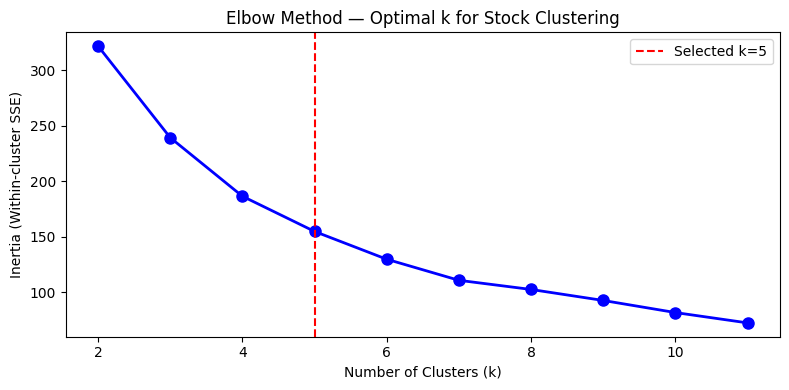


Cluster sizes:
cluster
0    38
1    21
2     2
3     8
4    25
Name: count, dtype: int64


In [78]:

cluster_profile, kmeans_model, cluster_scaler = cluster_stocks(simple_ret)


### Interprétation
- Chaque cluster regroupe des actions au profil similaire.  
- Les tailles de clusters reflètent la répartition des titres :  
  - **Cluster 0 (38 titres)** : groupe dominant, profil commun.  
  - **Cluster 2 (2 titres)** : groupe marginal, comportement atypique.  
- L’**Elbow plot** sauvegardé (`step3_elbow.png`) aide à valider le choix de `n_clusters`.  


# 3.3 — Supervised Classification Models


# Machine Learning Model Training

> *Entraînement et évaluation de plusieurs modèles ML avec validation croisée temporelle*

La fonction **`train_ml_models(X, y, n_splits=5)`** entraîne plusieurs modèles de classification supervisée sur des données financières ou de marché.  
Elle utilise une **TimeSeriesSplit cross-validation** afin de respecter la structure temporelle des données (pas de mélange passé/futur).

## Modèles inclus
- **Logistic Regression** : modèle linéaire de base, robuste avec `class_weight='balanced'`.  
- **Random Forest** : ensemble d’arbres de décision, limité en profondeur pour éviter l’overfitting.  
- **Gradient Boosting** : boosting séquentiel avec faible learning rate.  
- **XGBoost** : version optimisée du boosting, avec régularisation et sous-échantillonnage.

## Méthodologie
1. **Split temporel** : découpage des données en `n_splits` (par défaut 5) via `TimeSeriesSplit`.  
2. **Standardisation** : normalisation des features avec `StandardScaler` à chaque fold.  
3. **Entraînement** : chaque modèle est ajusté sur l’ensemble train.  
4. **Évaluation** : calcul de l’**AUC (Area Under ROC Curve)** sur l’ensemble test.  
5. **Agrégation** : moyenne et écart-type des AUC sur les folds.

## Paramètres
| Nom | Type | Défaut | Description |
|-----|------|--------|-------------|
| `X` | pd.DataFrame | – | Matrice des features |
| `y` | pd.Series | – | Labels (cible binaire) |
| `n_splits` | int | 5 | Nombre de splits temporels |

## Retour
| Variable | Type | Description |
|----------|------|-------------|
| `results` | dict | Résultats par modèle : AUC_mean, AUC_std, scores |
| `models` | dict | Dictionnaire des modèles entraînés |



In [79]:

def train_ml_models(X, y, n_splits=5):
    
    models = {
        'Logistic Regression': LogisticRegression(
            C=0.1, max_iter=1000, class_weight='balanced'
        ),
        'Random Forest': RandomForestClassifier(
            n_estimators=200,
            max_depth=5,
            min_samples_leaf=20,
            class_weight='balanced',
            random_state=42
        ),
        'Gradient Boosting': GradientBoostingClassifier(
            n_estimators=100,
            max_depth=3,
            learning_rate=0.05,
            random_state=42
        ),
        'XGBoost': xgb.XGBClassifier(
            n_estimators=200,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            use_label_encoder=False,
            eval_metric='logloss',
            random_state=42
        ),
    }
    
    tscv    = TimeSeriesSplit(n_splits=n_splits)
    results = {}
    
    for name, model in models.items():
        auc_scores = []
        
        for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
            
            # Scale features
            scaler  = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test  = scaler.transform(X_test)
            
            # Train
            model.fit(X_train, y_train)
            
            # Evaluate
            y_prob = model.predict_proba(X_test)[:, 1]
            auc    = roc_auc_score(y_test, y_prob)
            auc_scores.append(auc)
        
        results[name] = {
            'AUC_mean' : np.mean(auc_scores),
            'AUC_std'  : np.std(auc_scores),
            'scores'   : auc_scores
        }
        print(f"{name:25s} | AUC: {np.mean(auc_scores):.4f} "
              f"± {np.std(auc_scores):.4f}")
    
    return results, models




## Exemple de sortie


In [ ]:

results, trained_models = train_ml_models(X, y)


Logistic Regression       | AUC: 0.5022 ± 0.0469
Random Forest             | AUC: 0.5132 ± 0.0458
Gradient Boosting         | AUC: 0.5035 ± 0.0406
XGBoost                   | AUC: 0.5001 ± 0.0385



## Interprétation
- Les **AUC ≈ 0.50** indiquent que les modèles ne discriminent pas mieux qu’un tirage aléatoire(Like a simple Guessing i).  
- Cela peut provenir de :
  - Features peu informatives ou bruitées.  
  - Labels déséquilibrés ou mal définis.  
  - Fenêtre temporelle trop courte ou trop longue.  
- Ces résultats suggèrent qu’il faut **réviser la construction des features** ou **tester d’autres horizons de prédiction** pour améliorer la performance.



# ─────────────────────────────────────────────────────────────
# 3.4 — Feature Importance
# ─────────────────────────────────────────────────────────────

# 
    Visualize which features the model relies on most.
    High importance = feature is critical for prediction.
    

# Feature Importance Plot

> *Visualisation des variables les plus influentes dans un modèle ML*

La fonction **`plot_feature_importance(model, feature_names, top_n=15)`** génère un graphique en barres horizontales des **features les plus importantes** utilisées par un modèle de Machine Learning.  
Elle permet d’identifier les variables qui contribuent le plus aux prédictions.

## Méthodologie
1. **Extraction des importances** :
   - Si le modèle possède l’attribut `feature_importances_` (ex. Random Forest, Gradient Boosting, XGBoost), on l’utilise directement.  
   - Si le modèle possède l’attribut `coef_` (ex. Logistic Regression), on prend la valeur absolue des coefficients.  
   - Sinon, la fonction ne retourne rien.

2. **Construction de la série** :
   - Les importances sont converties en `pd.Series` avec les noms des features.  
   - On sélectionne les `top_n` plus importantes (par défaut 15).  
   - Les valeurs sont triées pour un affichage clair.

3. **Visualisation** :
   - Graphique en barres horizontales (`barh`) avec `matplotlib`.  
   - Sauvegarde automatique du graphique sous `step3_feature_importance.png`.  
   - Affichage interactif avec `plt.show()`.

## Paramètres
| Nom | Type | Défaut | Description |
|-----|------|--------|-------------|
| `model` | sklearn model | – | Modèle entraîné (doit avoir `feature_importances_` ou `coef_`) |
| `feature_names` | list | – | Liste des noms des features |
| `top_n` | int | 15 | Nombre de variables les plus importantes à afficher |

## Retour
- Aucun objet retourné.  
- Génère un **graphique en barres horizontales** des importances des features.  
- Sauvegarde le graphique en `.png`.

## Interprétation
- Les variables en haut du graphique sont celles qui influencent le plus les prédictions du modèle.  
- Une importance élevée signifie que la feature contribue fortement à la décision.  
- Permet de :
  - Identifier les **drivers principaux** du modèle.  
  - Détecter les variables **peu utiles** ou redondantes.  
  - Améliorer le **feature engineering** en se concentrant sur les variables les plus pertinentes.


In [81]:
def plot_feature_importance(model, feature_names, top_n=15):
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    elif hasattr(model, 'coef_'):
        importances = np.abs(model.coef_[0])
    else:
        return
    
    feat_imp = pd.Series(importances, index=feature_names)
    feat_imp = feat_imp.nlargest(top_n).sort_values()
    
    plt.figure(figsize=(10, 6))
    feat_imp.plot(kind='barh', color='steelblue', edgecolor='white')
    plt.title(f'Top {top_n} Feature Importances')
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.savefig('step3_feature_importance.png', dpi=150)
    plt.show()

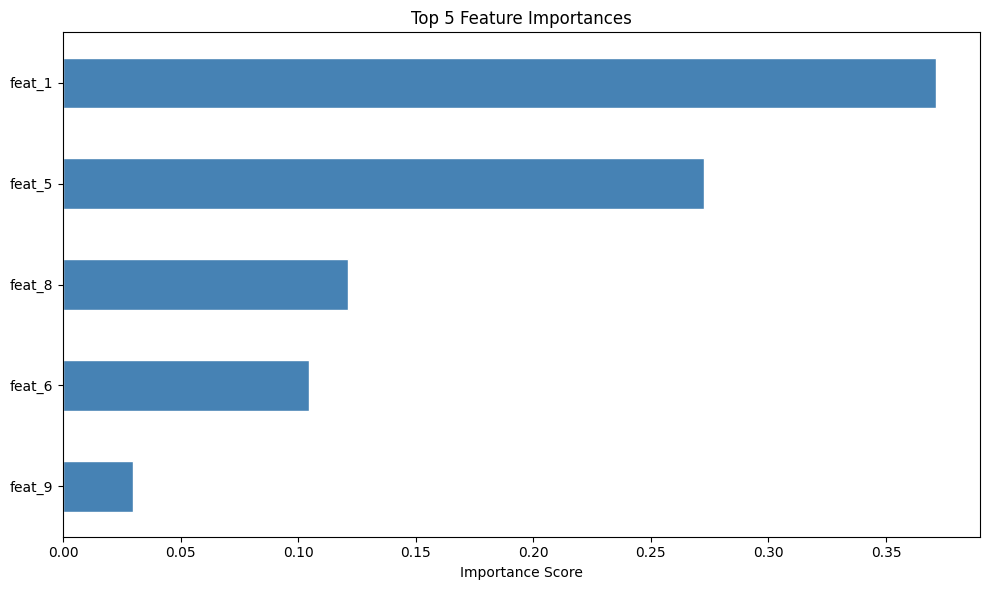

In [87]:
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# Générer des données factices
feature_names = [f"feat_{i}" for i in range(X.shape[1])]
X = pd.DataFrame(X, columns=feature_names)

# Entraîner un modèle
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

# Tester la fonction
plot_feature_importance(model, feature_names, top_n=5)


# ─────────────────────────────────────────────────────────────

# STEP 4 — Portfolio Construction
# ─────────────────────────────────────────────────────────────


In [88]:
from scipy.optimize import minimize


## 4.1 — Portfolio Metrics


In [89]:
def portfolio_performance(weights, mean_returns, cov_matrix,
                           risk_free_rate=0.05/252):
    """
    Compute portfolio expected return, volatility, and Sharpe ratio.
    
    Portfolio Return      : μ_p = w^T × μ
    Portfolio Variance    : σ²_p = w^T × Σ × w
    Portfolio Volatility  : σ_p = sqrt(σ²_p)
    Sharpe Ratio          : S = (μ_p - RF) / σ_p
    
    Parameters:
    -----------
    weights       : array of portfolio weights (sum = 1)
    mean_returns  : expected daily returns per asset
    cov_matrix    : covariance matrix of returns
    risk_free_rate: daily risk-free rate
    """
    port_return = np.dot(weights, mean_returns) * 252
    port_vol    = np.sqrt(
        weights @ cov_matrix @ weights
    ) * np.sqrt(252)
    sharpe      = (port_return - risk_free_rate * 252) / port_vol
    
    return port_return, port_vol, sharpe


## 4.2 — Efficient Frontier


In [90]:
def compute_efficient_frontier(returns, n_portfolios=5000,
                                risk_free=0.05):
    """
    Monte Carlo simulation of random portfolios to trace
    the Efficient Frontier (Markowitz, 1952).
    
    The Efficient Frontier is the set of portfolios that
    maximize return for a given level of risk.
    
    Key portfolios on the frontier:
    - Minimum Variance Portfolio (MVP)  : lowest σ_p
    - Maximum Sharpe Portfolio (MSR)    : highest Sharpe ratio
    - Maximum Return Portfolio          : highest μ_p
    """
    mu  = returns.mean()
    Sigma = returns.cov()
    n   = len(mu)
    
    port_returns  = []
    port_vols     = []
    port_sharpes  = []
    port_weights  = []
    
    np.random.seed(42)
    
    for _ in range(n_portfolios):
        # Random weights (sum to 1)
        w = np.random.dirichlet(np.ones(n))
        
        r, v, s = portfolio_performance(
            w, mu, Sigma, risk_free/252
        )
        
        port_returns.append(r)
        port_vols.append(v)
        port_sharpes.append(s)
        port_weights.append(w)
    
    frontier_df = pd.DataFrame({
        'Return'    : port_returns,
        'Volatility': port_vols,
        'Sharpe'    : port_sharpes,
    })
    
    # Plot
    plt.figure(figsize=(12, 8))
    sc = plt.scatter(
        frontier_df['Volatility'],
        frontier_df['Return'],
        c=frontier_df['Sharpe'],
        cmap='viridis', alpha=0.6, s=10
    )
    plt.colorbar(sc, label='Sharpe Ratio')
    
    # Mark key portfolios
    best_sharpe = frontier_df['Sharpe'].idxmax()
    min_vol     = frontier_df['Volatility'].idxmin()
    
    plt.scatter(
        frontier_df.loc[best_sharpe, 'Volatility'],
        frontier_df.loc[best_sharpe, 'Return'],
        marker='*', s=500, color='red',
        label='Max Sharpe Portfolio', zorder=5
    )
    plt.scatter(
        frontier_df.loc[min_vol, 'Volatility'],
        frontier_df.loc[min_vol, 'Return'],
        marker='D', s=200, color='blue',
        label='Min Variance Portfolio', zorder=5
    )
    plt.xlabel('Annual Volatility (Risk)')
    plt.ylabel('Annual Expected Return')
    plt.title('Efficient Frontier — Monte Carlo Simulation')
    plt.legend()
    plt.tight_layout()
    plt.savefig('step4_efficient_frontier.png', dpi=150)
    plt.show()
    
    return frontier_df, port_weights



## 4.3 — Optimize: Maximum Sharpe Ratio Portfolio


In [91]:
def max_sharpe_portfolio(returns, risk_free=0.05,
                          long_only=True, max_weight=0.15):
    """
    Solve the optimization problem:
    
    Maximize:   (μ_p - RF) / σ_p     (Sharpe ratio)
    Subject to: Σ w_i = 1
                w_i >= 0            (long-only)
                w_i <= max_weight   (concentration limit)
    
    Uses Sequential Quadratic Programming (scipy minimize).
    """
    mu    = returns.mean()
    Sigma = returns.cov()
    n     = len(mu)
    
    # Objective: negative Sharpe (we minimize)
    def neg_sharpe(w):
        r, v, s = portfolio_performance(w, mu, Sigma, risk_free/252)
        return -s
    
    # Constraints
    constraints = [
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}
    ]
    
    # Bounds
    bounds = [(0, max_weight) if long_only else (-0.2, max_weight)
              for _ in range(n)]
    
    # Initial guess: equal weights
    w0 = np.ones(n) / n
    
    result = minimize(
        neg_sharpe,
        w0,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints,
        options={'maxiter': 1000, 'ftol': 1e-9}
    )
    
    opt_weights = pd.Series(result.x, index=returns.columns)
    r, v, s     = portfolio_performance(
        result.x, mu, Sigma, risk_free/252
    )
    
    print(f"\n{'='*50}")
    print(f"Max Sharpe Portfolio:")
    print(f"  Expected Return : {r:.2%}")
    print(f"  Volatility      : {v:.2%}")
    print(f"  Sharpe Ratio    : {s:.4f}")
    print(f"  Non-zero weights: {(opt_weights > 0.01).sum()}")
    print(f"{'='*50}")
    
    # Plot weights
    opt_weights[opt_weights > 0.01].sort_values(ascending=True).plot(
        kind='barh', figsize=(10, 6), color='steelblue'
    )
    plt.title('Max Sharpe Portfolio — Optimal Weights')
    plt.xlabel('Weight')
    plt.tight_layout()
    plt.savefig('step4_optimal_weights.png', dpi=150)
    plt.show()
    
    return opt_weights



## 4.4 — ML-Enhanced Portfolio Selection


In [92]:
def ml_portfolio_selection(ml_model, X_current, tickers,
                            returns, top_k=30):
    """
    Use ML model predictions to pre-screen stocks,
    then optimize weights on the selected universe.
    
    Workflow:
    ---------
    1. ML model scores each stock (probability of outperforming)
    2. Select top_k stocks with highest BUY probability
    3. Run Markowitz optimization on selected universe
    4. Return final portfolio weights
    """
    # Step 1: Score stocks
    proba   = ml_model.predict_proba(X_current)[:, 1]
    scores  = pd.Series(proba, index=tickers)
    
    # Step 2: Select universe
    selected = scores.nlargest(top_k).index
    print(f"ML selected {len(selected)} stocks for optimization")
    
    # Step 3: Optimize on selected universe
    opt_weights = max_sharpe_portfolio(
        returns[selected], risk_free=0.05
    )
    
    return opt_weights, scores

# STEP 5 — Backtesting


# 5.1 — Performance Metrics


Complete performance evaluation of a strategy.
    
    Key Metrics:
    ============
    
    1. Total Return    : Σ(1+r_t) - 1
    
    2. CAGR            : (1 + Total_Return)^(1/years) - 1
    
    3. Sharpe Ratio    : (μ - RF) / σ × sqrt(252)
       > 1.0 = good, > 2.0 = excellent
    
    4. Sortino Ratio   : (μ - RF) / σ_downside × sqrt(252)
       Uses only negative returns in denominator
       Better than Sharpe for asymmetric distributions
    
    5. Max Drawdown    : max(1 - P_t / max(P_τ, τ≤t))
       Worst peak-to-trough loss
    
    6. Calmar Ratio    : CAGR / |Max Drawdown|
       How much return per unit of max loss?
    
    7. Win Rate        : % of days with positive return
    
    8. Profit Factor   : sum(gains) / sum(|losses|)

In [93]:
def compute_performance_metrics(returns_series, risk_free=0.05,
                                 freq=252):
    
    r = returns_series.dropna()
    
    # Cumulative wealth
    wealth = (1 + r).cumprod()
    
    # Total return
    total_return = wealth.iloc[-1] - 1
    
    # CAGR
    n_years = len(r) / freq
    cagr    = (1 + total_return) ** (1 / n_years) - 1
    
    # Sharpe Ratio
    excess_ret = r - risk_free / freq
    sharpe     = excess_ret.mean() / r.std() * np.sqrt(freq)
    
    # Sortino Ratio
    downside   = r[r < 0].std()
    sortino    = excess_ret.mean() / downside * np.sqrt(freq)
    
    # Maximum Drawdown
    rolling_max = wealth.cummax()
    drawdown    = (wealth / rolling_max) - 1
    max_dd      = drawdown.min()
    
    # Calmar Ratio
    calmar = cagr / abs(max_dd)
    
    # Win Rate
    win_rate = (r > 0).mean()
    
    # Profit Factor
    gains   = r[r > 0].sum()
    losses  = r[r < 0].sum()
    pf      = gains / abs(losses) if losses != 0 else np.inf
    
    # Volatility
    annual_vol = r.std() * np.sqrt(freq)
    
    metrics = {
        'Total Return'   : f"{total_return:.2%}",
        'CAGR'           : f"{cagr:.2%}",
        'Annual Vol'     : f"{annual_vol:.2%}",
        'Sharpe Ratio'   : f"{sharpe:.4f}",
        'Sortino Ratio'  : f"{sortino:.4f}",
        'Max Drawdown'   : f"{max_dd:.2%}",
        'Calmar Ratio'   : f"{calmar:.4f}",
        'Win Rate'       : f"{win_rate:.2%}",
        'Profit Factor'  : f"{pf:.4f}",
    }
    
    return metrics, drawdown, wealth



# 5.2 — Full Backtesting Engine



    Walk-Forward Backtesting Engine.
    
    CRITICAL RULES to avoid look-ahead bias:
    -----------------------------------------
    1. Train only on data BEFORE the current date
    2. Predict only on data available AT the current date
    3. Execute trades AT the next open (T+1), not T
    4. Apply transaction costs on each rebalancing
    
    Rebalancing:
    -----------
    At each rebalancing date:
    1. Train ML model on historical data
    2. Score all stocks in universe
    3. Select top_k stocks by ML score
    4. Optimize weights (Max Sharpe)
    5. Compute portfolio returns until next rebalancing
    
    Parameters:
    -----------
    transaction_cost : bid-ask spread + commission (e.g. 0.1%)
    

In [94]:

def backtest_ml_strategy(prices, returns, features_dict,
                          ml_model, rebal_freq='ME',
                          top_k=30, transaction_cost=0.001):
    
    rebal_dates    = returns.resample(rebal_freq).last().index
    portfolio_rets = []
    weights_history = {}
    
    for i, date in enumerate(rebal_dates[12:-1]):  # warm-up period
        
        print(f"Rebalancing: {date.date()}", end='\r')
        
        # ── Step 1: Get historical data up to date
        hist_returns = returns.loc[:date]
        
        # ── Step 2: Build features for current date
        current_feats = {}
        for fname, fdf in features_dict.items():
            if date in fdf.index:
                current_feats[fname] = fdf.loc[date]
        
        if not current_feats:
            continue
            
        X_current = pd.DataFrame(current_feats).dropna()
        
        if len(X_current) < top_k:
            continue
        
        # Cross-sectional normalization
        X_scaled = (X_current - X_current.mean()) / X_current.std()
        X_scaled = X_scaled.fillna(0)
        
        # ── Step 3: ML Scoring
        try:
            scores = pd.Series(
                ml_model.predict_proba(X_scaled.values)[:, 1],
                index=X_scaled.index
            )
        except Exception:
            continue
        
        # ── Step 4: Select top stocks
        selected = scores.nlargest(top_k).index
        selected = [s for s in selected if s in hist_returns.columns]
        
        if len(selected) < 5:
            continue
        
        # ── Step 5: Optimize weights
        try:
            opt_w = max_sharpe_portfolio(
                hist_returns[selected].tail(252),
                risk_free=0.05
            )
        except Exception:
            opt_w = pd.Series(
                1/len(selected),
                index=selected
            )
        
        # ── Step 6: Compute returns until next rebalancing
        next_date = rebal_dates[i + 2] if i + 2 < len(rebal_dates) \
                    else returns.index[-1]
        
        period_rets = returns.loc[date:next_date, selected]
        
        # Apply weights
        if len(period_rets) > 0 and len(opt_w) > 0:
            common    = period_rets.columns.intersection(opt_w.index)
            w_aligned = opt_w[common]
            w_aligned = w_aligned / w_aligned.sum()  # renormalize
            
            port_ret = period_rets[common].dot(w_aligned)
            
            # Apply transaction cost on first day
            port_ret.iloc[0] -= transaction_cost
            
            portfolio_rets.append(port_ret)
            weights_history[date] = w_aligned
    
    if not portfolio_rets:
        print("No portfolio returns computed!")
        return None, None
    
    port_returns = pd.concat(portfolio_rets).sort_index()
    port_returns = port_returns[~port_returns.index.duplicated()]
    
    print(f"\nBacktest complete: {len(port_returns)} trading days")
    
    return port_returns, weights_history

# STEP 6 — Benchmark Comparison & Final Evaluation


## 6.1 — Download S&P 500 Benchmark



    Download S&P 500 index as benchmark.
    Compute daily returns for comparison.
    

In [ ]:
def get_benchmark(start, end, ticker='^GSPC'):
    
    bench = yf.download(ticker, start=start, end=end,
                        auto_adjust=True, progress=False)['Close']
    bench_ret = bench.pct_change().dropna()
    bench_ret.name = 'S&P 500'
    return bench_ret

benchmark = get_benchmark(START, END)


## 6.2 — Full Performance Dashboard



    Complete side-by-side comparison:
    Strategy vs S&P 500 Benchmark
    
    Panels:
    1. Cumulative wealth curve
    2. Drawdown profile
    3. Rolling Sharpe (1-year window)
    4. Monthly return heatmap
    5. Performance metrics table
    

In [ ]:
def performance_dashboard(strategy_ret, benchmark_ret,
                           strategy_name='ML Strategy'):
    
    # Align dates
    common = strategy_ret.index.intersection(benchmark_ret.index)
    s_ret  = strategy_ret.loc[common]
    b_ret  = benchmark_ret.loc[common]
    
    # Compute wealth curves
    s_wealth = (1 + s_ret).cumprod()
    b_wealth = (1 + b_ret).cumprod()
    
    # Compute metrics
    s_metrics, s_dd, _ = compute_performance_metrics(s_ret)
    b_metrics, b_dd, _ = compute_performance_metrics(b_ret)
    
    # ── Figure
    fig = plt.figure(figsize=(20, 16))
    gs  = fig.add_gridspec(3, 2, hspace=0.4, wspace=0.3)
    
    # Panel 1: Cumulative Returns
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(s_wealth.index, s_wealth.values,
             label=strategy_name, color='#2196F3', linewidth=2)
    ax1.plot(b_wealth.index, b_wealth.values,
             label='S&P 500', color='#FF9800',
             linewidth=2, linestyle='--')
    ax1.fill_between(s_wealth.index,
                     s_wealth.values, b_wealth.values,
                     where=s_wealth.values >= b_wealth.values,
                     alpha=0.1, color='green', label='Outperformance')
    ax1.fill_between(s_wealth.index,
                     s_wealth.values, b_wealth.values,
                     where=s_wealth.values < b_wealth.values,
                     alpha=0.1, color='red', label='Underperformance')
    ax1.set_title('Cumulative Wealth — Strategy vs Benchmark',
                  fontsize=14, fontweight='bold')
    ax1.set_ylabel('Portfolio Value ($1 invested)')
    ax1.legend(loc='upper left')
    ax1.grid(alpha=0.3)
    
    # Panel 2: Drawdown
    ax2 = fig.add_subplot(gs[1, 0])
    ax2.fill_between(s_dd.index, s_dd.values, 0,
                     color='#2196F3', alpha=0.4, label=strategy_name)
    ax2.fill_between(b_dd.index, b_dd.values, 0,
                     color='#FF9800', alpha=0.4, label='S&P 500')
    ax2.set_title('Drawdown Profile', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Drawdown (%)')
    ax2.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'{x:.0%}')
    )
    ax2.legend()
    ax2.grid(alpha=0.3)
    
    # Panel 3: Rolling Sharpe (252-day)
    ax3 = fig.add_subplot(gs[1, 1])
    roll_sharpe_s = (s_ret.rolling(252).mean() /
                     s_ret.rolling(252).std()) * np.sqrt(252)
    roll_sharpe_b = (b_ret.rolling(252).mean() /
                     b_ret.rolling(252).std()) * np.sqrt(252)
    ax3.plot(roll_sharpe_s.index, roll_sharpe_s.values,
             color='#2196F3', label=strategy_name, linewidth=1.5)
    ax3.plot(roll_sharpe_b.index, roll_sharpe_b.values,
             color='#FF9800', label='S&P 500', linewidth=1.5,
             linestyle='--')
    ax3.axhline(y=1, color='green', linestyle=':', alpha=0.7,
                label='Sharpe = 1.0')
    ax3.axhline(y=0, color='red', linestyle=':', alpha=0.7)
    ax3.set_title('Rolling 1-Year Sharpe Ratio',
                  fontsize=12, fontweight='bold')
    ax3.legend()
    ax3.grid(alpha=0.3)
    
    # Panel 4: Monthly Returns Heatmap
    ax4 = fig.add_subplot(gs[2, 0])
    monthly = s_ret.resample('ME').apply(
        lambda x: (1 + x).prod() - 1
    )
    monthly_pivot = monthly.groupby(
        [monthly.index.year, monthly.index.month]
    ).first().unstack()
    monthly_pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun',
                              'Jul','Aug','Sep','Oct','Nov','Dec']
    sns.heatmap(monthly_pivot, ax=ax4, cmap='RdYlGn',
                center=0, fmt='.1%', annot=True,
                annot_kws={'size': 7}, linewidths=0.5)
    ax4.set_title('Monthly Returns Heatmap — ML Strategy',
                  fontsize=12, fontweight='bold')
    
    # Panel 5: Metrics Table
    ax5 = fig.add_subplot(gs[2, 1])
    ax5.axis('off')
    
    metrics_data = []
    for key in s_metrics.keys():
        metrics_data.append([key, s_metrics[key], b_metrics[key]])
    
    table = ax5.table(
        cellText=metrics_data,
        colLabels=['Metric', strategy_name, 'S&P 500'],
        loc='center',
        cellLoc='center'
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.8)
    
    # Color header
    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_facecolor('#0A1628')
            cell.set_text_props(color='white', fontweight='bold')
        elif row % 2 == 0:
            cell.set_facecolor('#F0F4FF')
    
    ax5.set_title('Performance Metrics Summary',
                  fontsize=12, fontweight='bold', pad=20)
    
    plt.suptitle(f'ML Trading Strategy — Full Performance Report\n'
                 f'{common[0].date()} → {common[-1].date()}',
                 fontsize=16, fontweight='bold', y=1.01)
    
    plt.savefig('step6_performance_dashboard.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    
    return s_metrics, b_metrics


## 6.3 — Alpha & Beta Analysis (CAPM)


CAPM regression: r_p - RF = α + β(r_m - RF) + ε
    
    α (Alpha) : excess return not explained by market exposure
                Positive alpha = skill, not just market riding
    β (Beta)  : market sensitivity
                β=1 → same risk as market
                β<1 → defensive
                β>1 → aggressive
    
    Information Ratio : α / σ(ε)
    Tracks the consistency of alpha generation.

In [96]:
def compute_alpha_beta(strategy_ret, benchmark_ret,
                        risk_free=0.05/252):
    
    from scipy import stats
    
    common = strategy_ret.index.intersection(benchmark_ret.index)
    s = strategy_ret.loc[common] - risk_free
    b = benchmark_ret.loc[common] - risk_free
    
    # OLS regression
    beta, alpha, r_value, p_value, std_err = stats.linregress(b, s)
    
    # Residuals (tracking error)
    residuals = s - (alpha + beta * b)
    info_ratio = alpha * 252 / (residuals.std() * np.sqrt(252))
    
    print(f"\n{'='*50}")
    print(f"CAPM Analysis:")
    print(f"  Alpha (annualized) : {alpha*252:.4f} ({alpha*252:.2%})")
    print(f"  Beta               : {beta:.4f}")
    print(f"  R²                 : {r_value**2:.4f}")
    print(f"  P-value (alpha)    : {p_value:.4f}")
    print(f"  Information Ratio  : {info_ratio:.4f}")
    print(f"{'='*50}")
    
    return alpha, beta, info_ratio

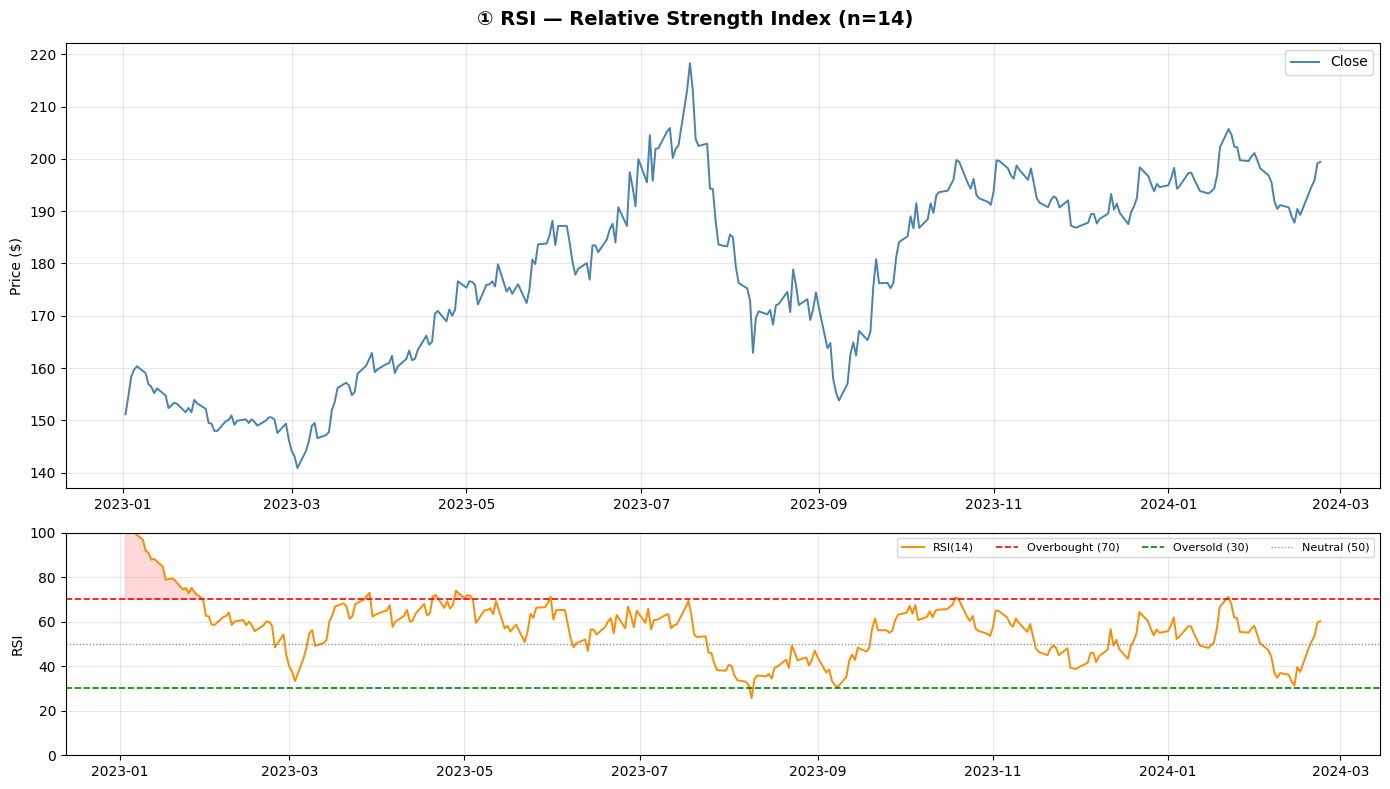

RSI — Last 10 values:
            close
2024-02-12  36.16
2024-02-13  33.21
2024-02-14  31.26
2024-02-15  39.57
2024-02-16  37.44
2024-02-19  48.24
2024-02-20  51.15
2024-02-21  53.58
2024-02-22  59.61
2024-02-23  60.15

Current RSI : 60.15
Overbought days (>70) : 32  |  Oversold days (<30) : 1


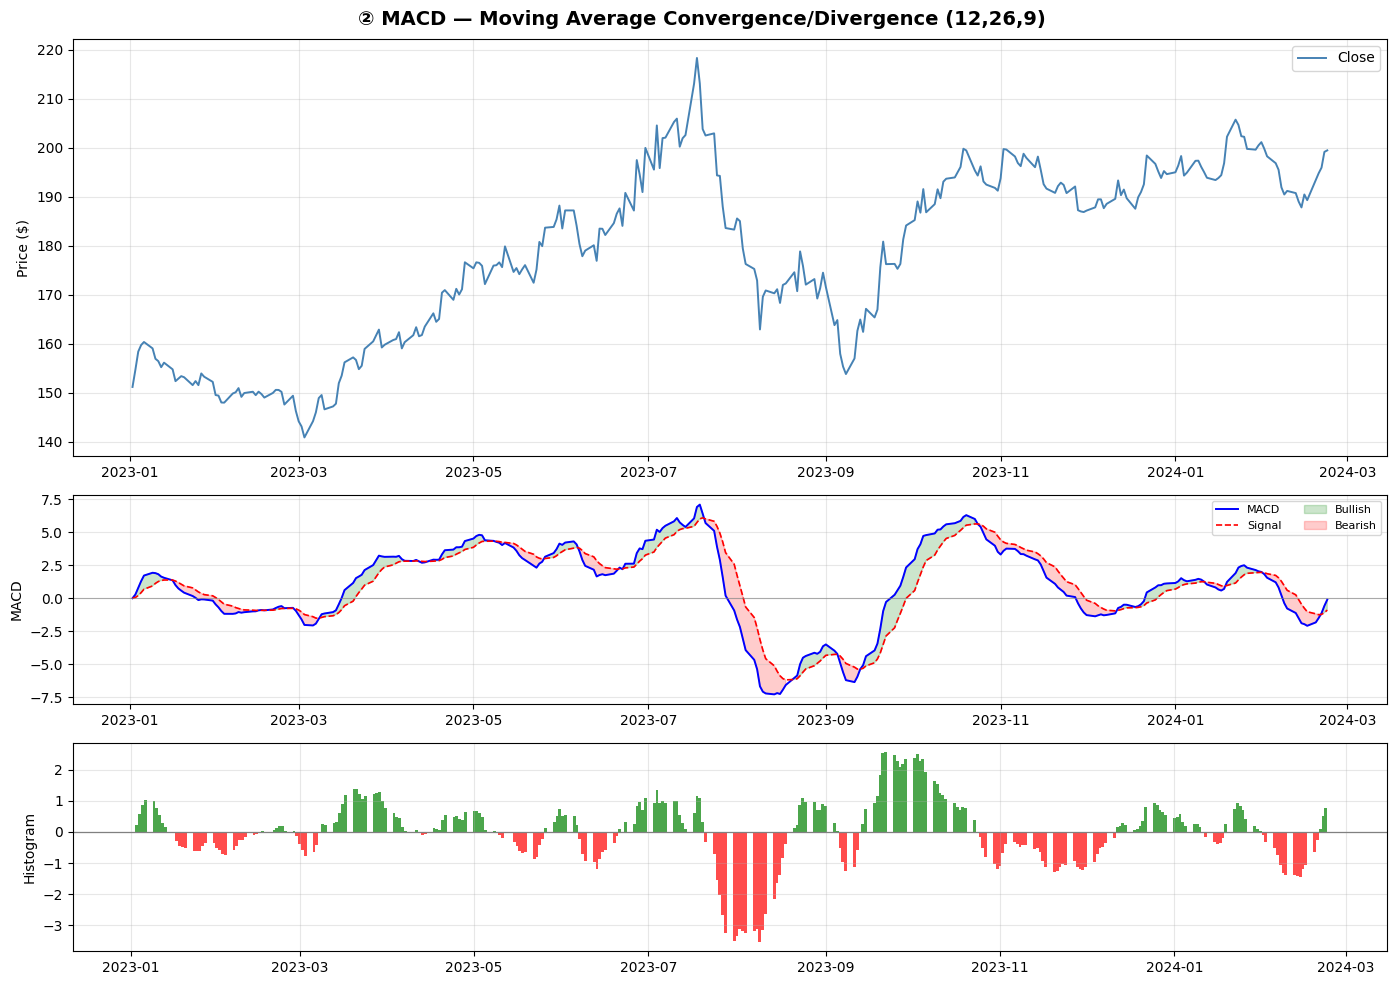

MACD — Last 10 values:
              MACD  Signal  Histogram
2024-02-12 -1.1182  0.2569    -1.3751
2024-02-13 -1.5082 -0.0961    -1.4121
2024-02-14 -1.8932 -0.4555    -1.4377
2024-02-15 -1.9627 -0.7570    -1.2057
2024-02-16 -2.0870 -1.0230    -1.0640
2024-02-19 -1.8290 -1.1842    -0.6448
2024-02-20 -1.4997 -1.2473    -0.2524
2024-02-21 -1.1332 -1.2245     0.0913
2024-02-22 -0.5770 -1.0950     0.5179
2024-02-23 -0.1099 -0.8980     0.7880


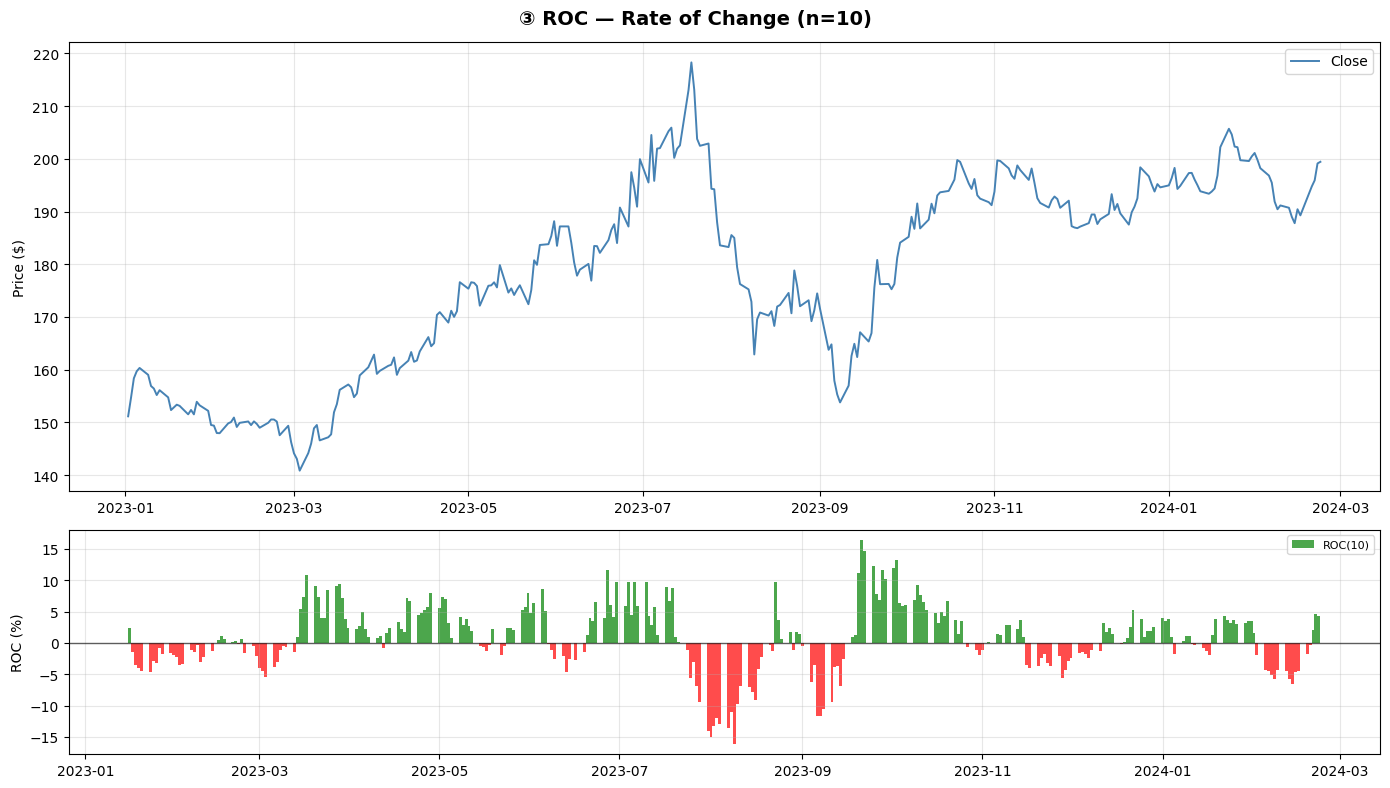

ROC — Last 10 values:
            ROC(10) %
2024-02-12     -4.440
2024-02-13     -5.711
2024-02-14     -6.621
2024-02-15     -4.682
2024-02-16     -4.511
2024-02-19     -1.721
2024-02-20     -0.364
2024-02-21      2.100
2024-02-22      4.563
2024-02-23      4.328

Current ROC : 4.328%


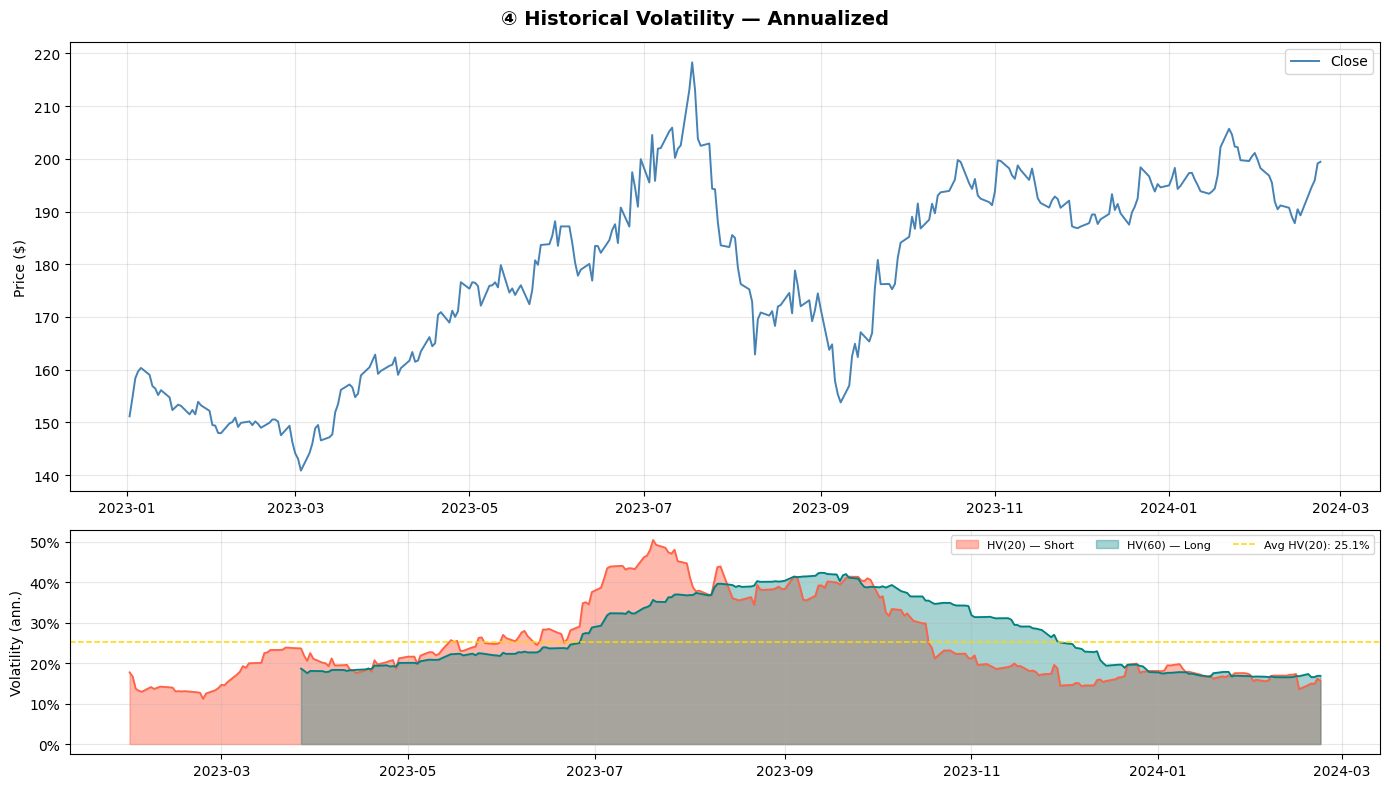

Historical Volatility — Last 10 values:
            HV(20)
2024-02-12  16.93%
2024-02-13  17.14%
2024-02-14  17.16%
2024-02-15  17.33%
2024-02-16  13.57%
2024-02-19  14.59%
2024-02-20  14.97%
2024-02-21  14.87%
2024-02-22  16.18%
2024-02-23  15.61%

Current HV(20) : 15.61%  |  Mean : 25.15%


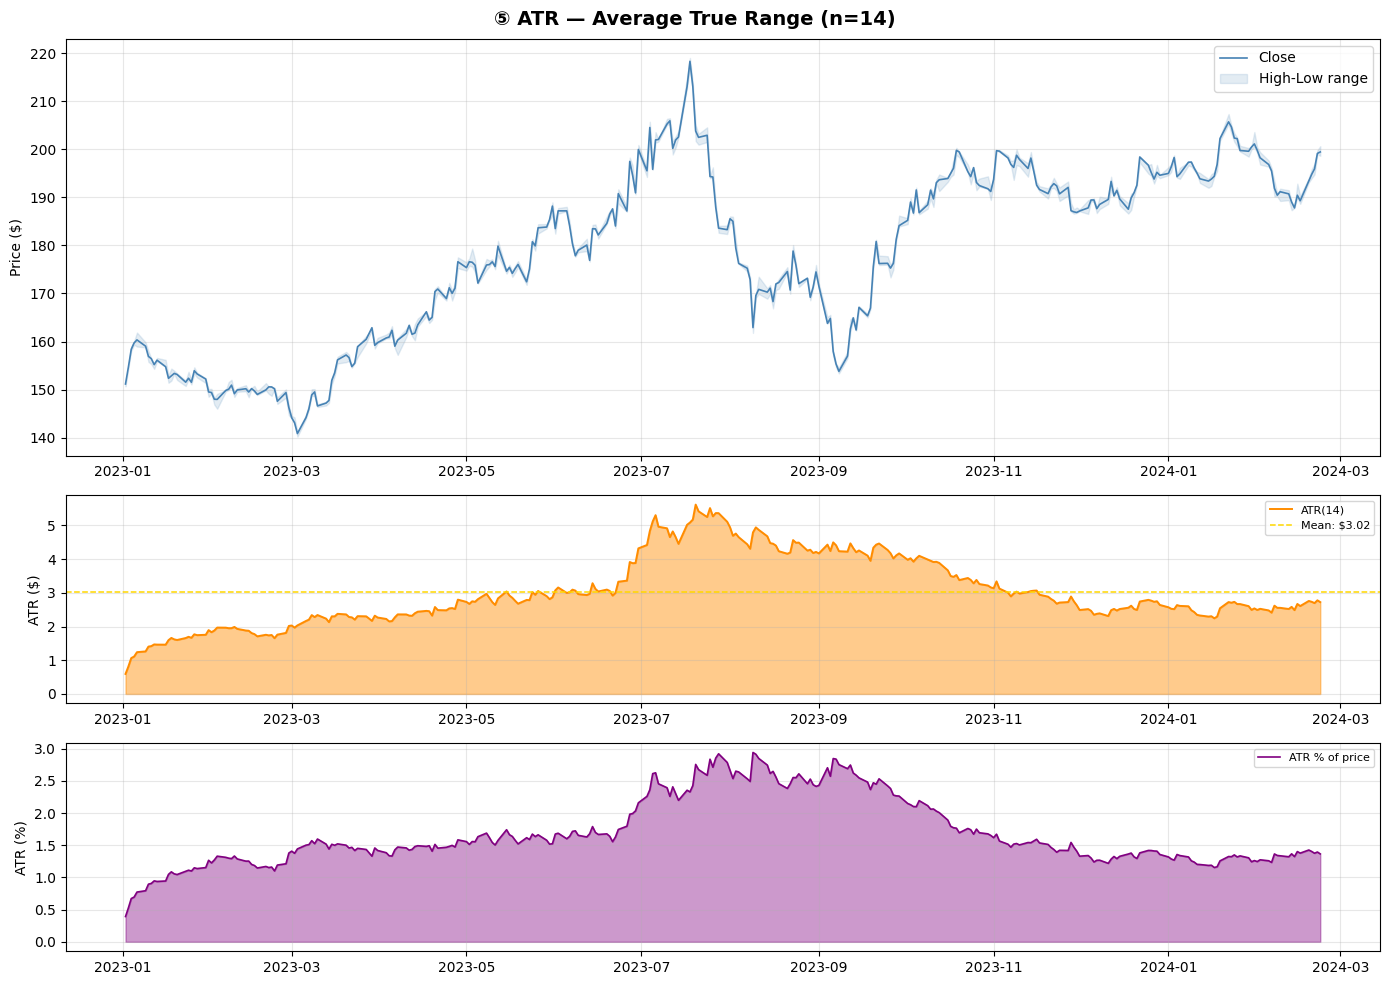

ATR — Last 10 values:
            ATR(14) $
2024-02-12     2.5203
2024-02-13     2.5836
2024-02-14     2.4867
2024-02-15     2.6696
2024-02-16     2.6076
2024-02-19     2.7586
2024-02-20     2.7338
2024-02-21     2.6951
2024-02-22     2.7780
2024-02-23     2.7237

Current ATR : $2.7237
Stop (2×ATR): $193.99


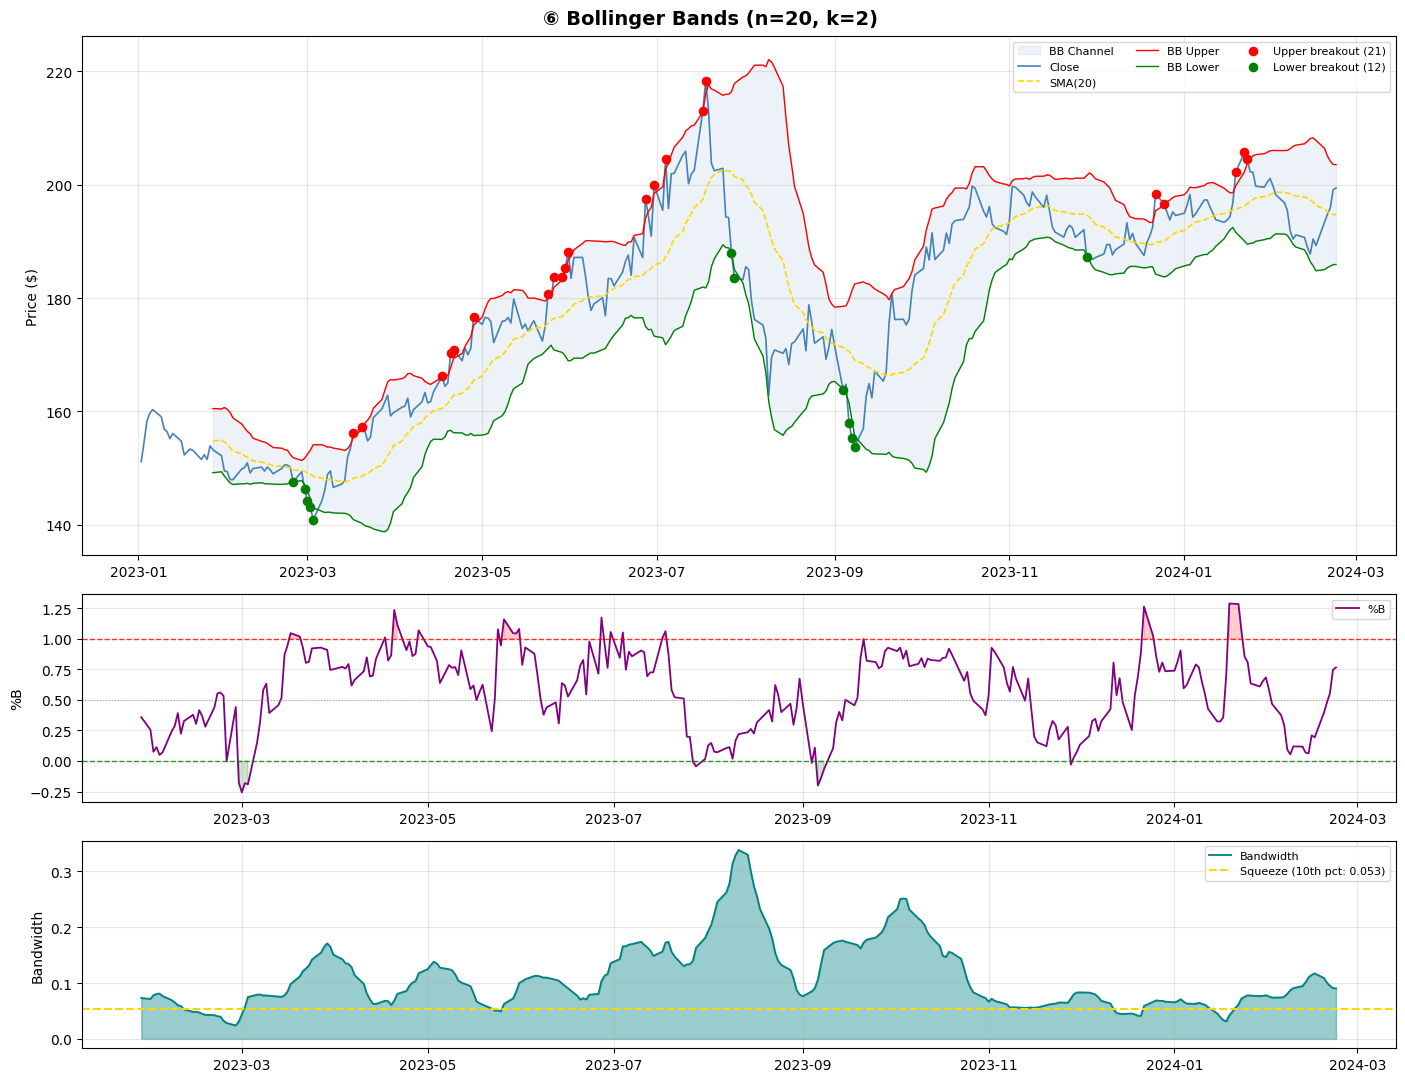

Bollinger Bands — Last 10 values:
              Close  BB_Upper  BB_Lower     %B  Bandwidth
2024-02-12  190.716   207.226   188.516  0.118      0.095
2024-02-13  189.005   207.648   187.615  0.069      0.101
2024-02-14  187.793   208.166   186.439  0.062      0.110
2024-02-15  190.434   208.273   185.693  0.210      0.115
2024-02-16  189.277   207.845   184.828  0.193      0.117
2024-02-19  193.434   206.409   185.037  0.393      0.109
2024-02-20  194.766   205.063   185.397  0.476      0.101
2024-02-21  195.913   204.171   185.649  0.554      0.095
2024-02-22  199.123   203.600   185.912  0.747      0.091
2024-02-23  199.434   203.550   185.932  0.766      0.090


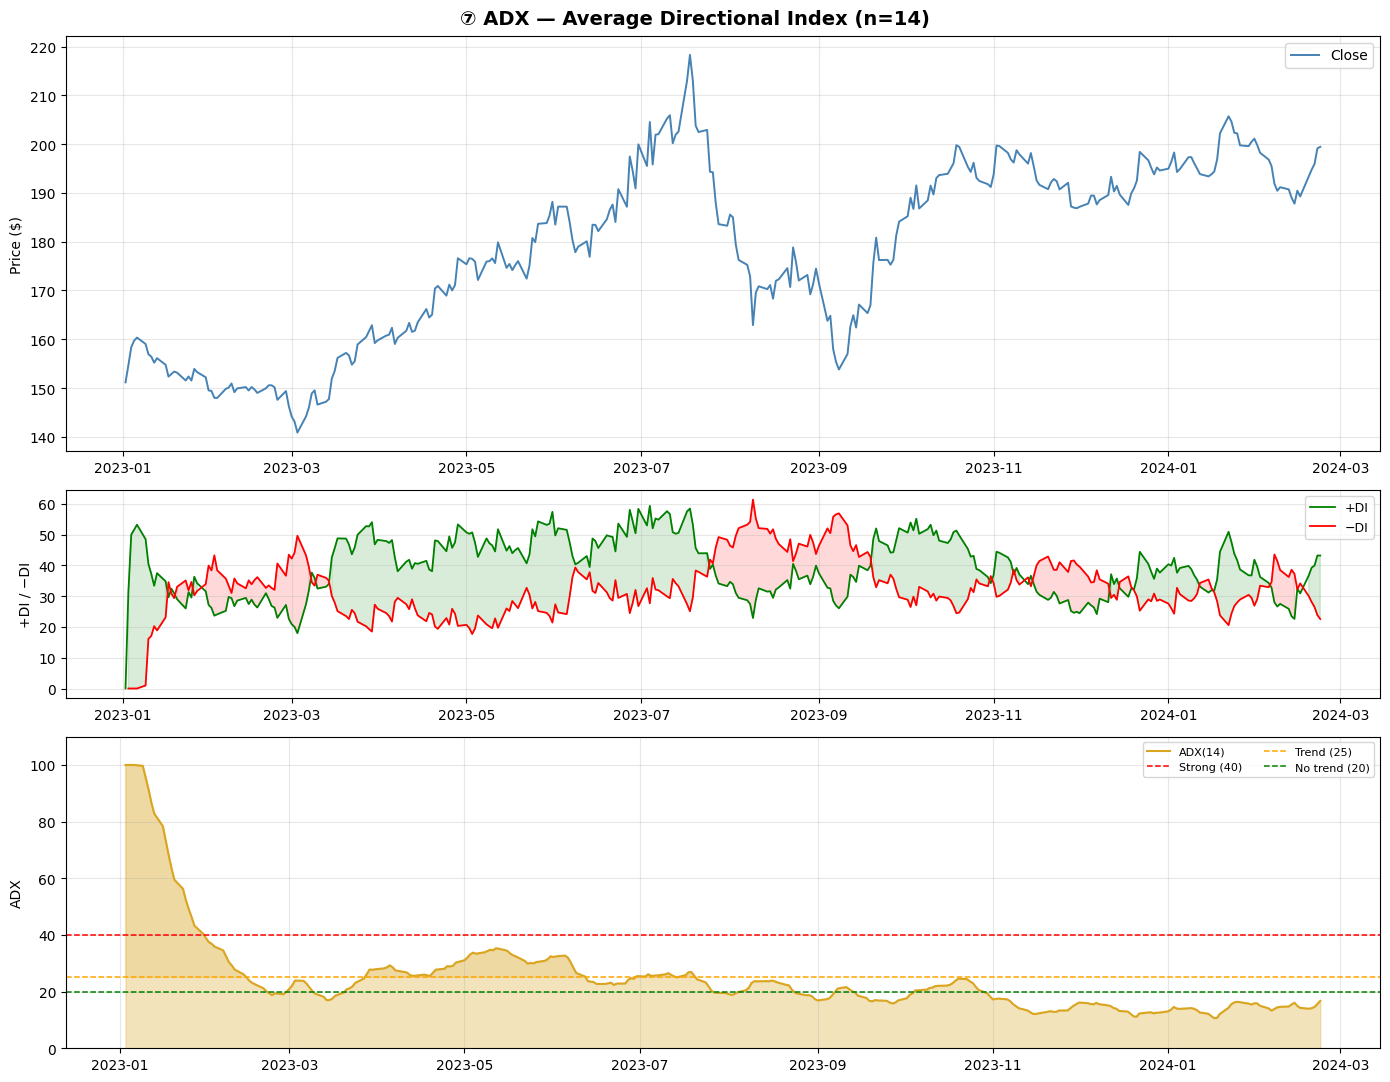

ADX — Last 10 values:
              ADX    +DI    −DI     Dir
2024-02-12  14.76  25.89  36.24  ↓ Bear
2024-02-13  15.45  23.45  38.61  ↓ Bear
2024-02-14  16.09  22.62  37.25  ↓ Bear
2024-02-15  14.97  32.51  32.22  ↑ Bull
2024-02-16  14.26  30.90  34.18  ↓ Bear
2024-02-19  13.97  36.79  30.00  ↑ Bull
2024-02-20  14.16  39.30  28.11  ↑ Bull
2024-02-21  14.60  39.97  26.48  ↑ Bull
2024-02-22  15.62  43.23  23.85  ↑ Bull
2024-02-23  16.74  43.22  22.59  ↑ Bull

Current ADX : 16.74


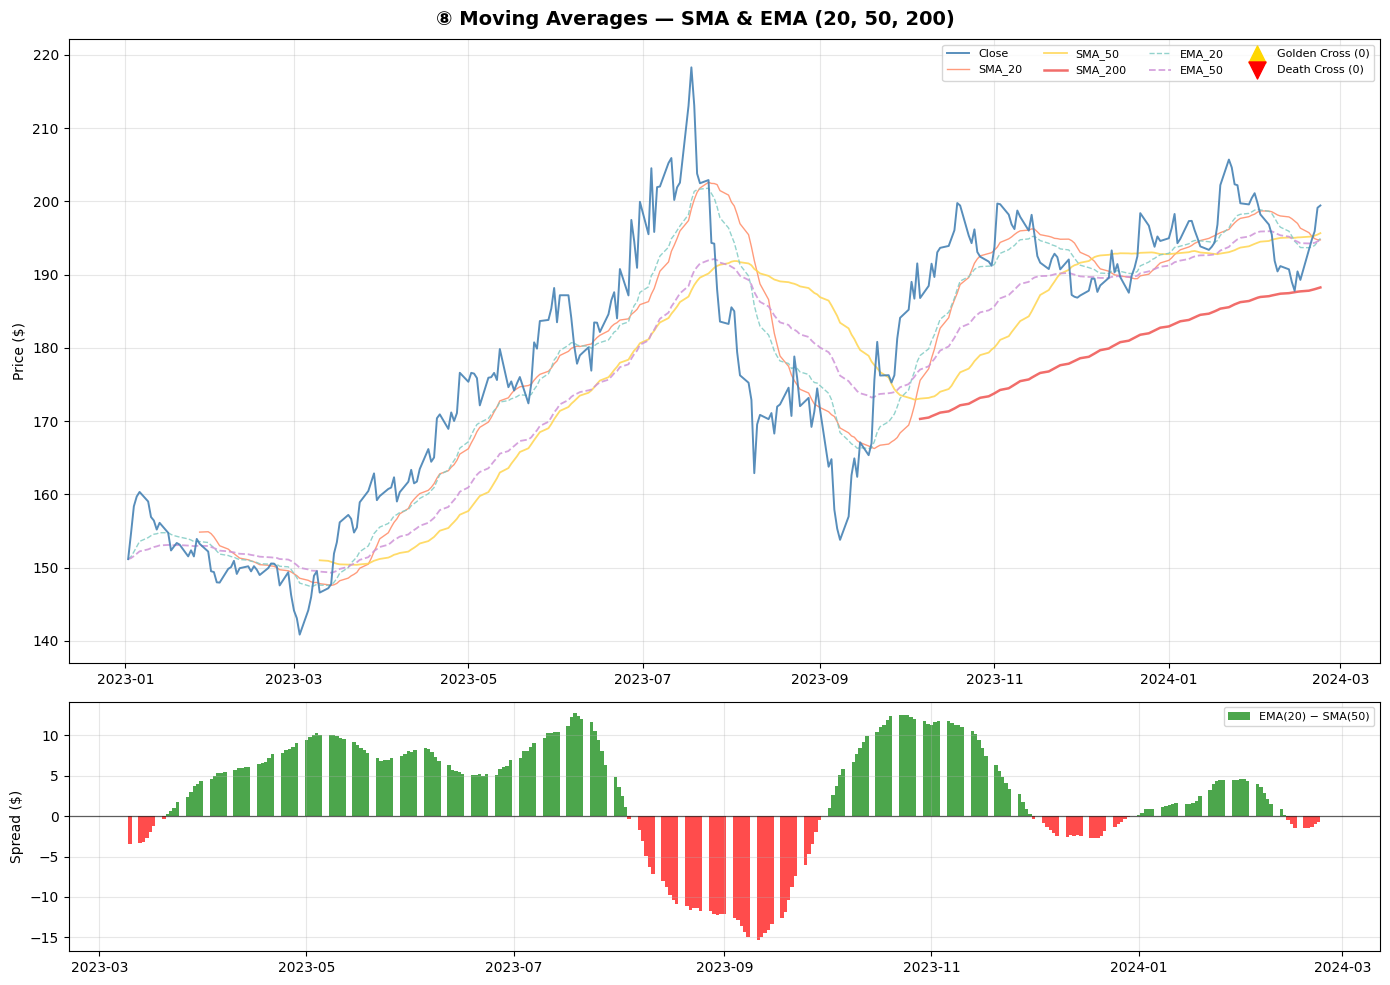

Moving Averages — Last 5 values:
             Close  SMA_20  SMA_50  SMA_200  EMA_20  EMA_50
2024-02-19  193.43  195.72  195.17   187.80  193.67  194.25
2024-02-20  194.77  195.23  195.20   187.90  193.77  194.27
2024-02-21  195.91  194.91  195.31   188.01  193.98  194.34
2024-02-22  199.12  194.76  195.46   188.13  194.47  194.53
2024-02-23  199.43  194.74  195.66   188.25  194.94  194.72

Current Price : $199.43
  SMA_20  : $194.74  (+2.41% ↑)
  SMA_50  : $195.66  (+1.93% ↑)
  SMA_200 : $188.25  (+5.94% ↑)
  EMA_20  : $194.94  (+2.31% ↑)
  EMA_50  : $194.72  (+2.42% ↑)


In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────────────────────────────────────
# SIMULATED DATA
# ─────────────────────────────────────────────────────────────────────────────
np.random.seed(42)
n     = 300
dates = pd.date_range(start='2023-01-01', periods=n, freq='B')

close_list, high_list, low_list = [], [], []
close = 150.0

for i in range(n):
    vol   = 0.015 if i < 100 else (0.025 if i < 200 else 0.012)
    trend = 0.0003 if i < 150 else -0.0002
    ret   = trend + vol * np.random.randn()
    close = close * (1 + ret)
    high  = close * (1 + abs(np.random.randn()) * 0.005)
    low   = close * (1 - abs(np.random.randn()) * 0.005)
    close_list.append(close)
    high_list.append(high)
    low_list.append(low)

df = pd.DataFrame({'close': close_list,
                   'high' : high_list,
                   'low'  : low_list}, index=dates)

prices  = df['close']
high    = df['high']
low     = df['low']
returns = prices.pct_change().dropna()

# ─────────────────────────────────────────────────────────────────────────────
# INDICATOR FUNCTIONS
# ─────────────────────────────────────────────────────────────────────────────

def compute_RSI(prices, n=14):
    delta    = prices.diff()
    gain     = delta.clip(lower=0)
    loss     = -delta.clip(upper=0)
    avg_gain = gain.ewm(alpha=1/n, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/n, adjust=False).mean()
    RS       = avg_gain / avg_loss
    return 100 - (100 / (1 + RS))

def compute_MACD(prices, fast=12, slow=26, signal=9):
    ema_fast  = prices.ewm(span=fast,   adjust=False).mean()
    ema_slow  = prices.ewm(span=slow,   adjust=False).mean()
    macd      = ema_fast - ema_slow
    sig_line  = macd.ewm(span=signal, adjust=False).mean()
    histogram = macd - sig_line
    return macd, sig_line, histogram

def compute_ROC(prices, n=10):
    return prices.pct_change(periods=n) * 100

def compute_historical_volatility(returns, window=20):
    return returns.rolling(window).std() * np.sqrt(252)

def compute_ATR(high, low, close, n=14):
    tr1 = high - low
    tr2 = (high - close.shift(1)).abs()
    tr3 = (low  - close.shift(1)).abs()
    TR  = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    return TR.ewm(alpha=1/n, adjust=False).mean()

def compute_bollinger_bands(prices, n=20, k=2):
    sma       = prices.rolling(n).mean()
    sigma     = prices.rolling(n).std()
    bb_upper  = sma + k * sigma
    bb_lower  = sma - k * sigma
    pct_b     = (prices - bb_lower) / (bb_upper - bb_lower)
    bandwidth = (bb_upper - bb_lower) / sma
    return bb_upper, bb_lower, pct_b, bandwidth

def compute_ADX(high, low, close, n=14):
    atr      = compute_ATR(high, low, close, n)
    plus_dm  = high.diff().clip(lower=0)
    minus_dm = (-low.diff()).clip(lower=0)
    mask     = plus_dm >= minus_dm
    plus_dm  = plus_dm.where(mask, 0)
    minus_dm = minus_dm.where(~mask, 0)
    plus_di  = 100 * plus_dm.ewm(alpha=1/n, adjust=False).mean() / atr
    minus_di = 100 * minus_dm.ewm(alpha=1/n, adjust=False).mean() / atr
    dx       = 100 * (plus_di - minus_di).abs() / (plus_di + minus_di)
    adx      = dx.ewm(alpha=1/n, adjust=False).mean()
    return adx, plus_di, minus_di

def compute_moving_averages(prices):
    return {
        'SMA_20' : prices.rolling(20).mean(),
        'SMA_50' : prices.rolling(50).mean(),
        'SMA_200': prices.rolling(200).mean(),
        'EMA_20' : prices.ewm(span=20, adjust=False).mean(),
        'EMA_50' : prices.ewm(span=50, adjust=False).mean(),
    }

# ─────────────────────────────────────────────────────────────────────────────
# COMPUTE ALL INDICATORS
# ─────────────────────────────────────────────────────────────────────────────
rsi                            = compute_RSI(prices, n=14)
macd, sig_line, histogram      = compute_MACD(prices)
roc                            = compute_ROC(prices, n=10)
hv                             = compute_historical_volatility(returns, window=20)
hv60                           = compute_historical_volatility(returns, window=60)
atr                            = compute_ATR(high, low, prices, n=14)
bb_upper, bb_lower, pct_b, bw  = compute_bollinger_bands(prices, n=20, k=2)
adx, plus_di, minus_di         = compute_ADX(high, low, prices, n=14)
mas                            = compute_moving_averages(prices)
sma20                          = prices.rolling(20).mean()

# ─────────────────────────────────────────────────────────────────────────────
# ① RSI
# ─────────────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8),
                                gridspec_kw={'height_ratios': [2, 1]})
fig.suptitle('① RSI — Relative Strength Index (n=14)', fontsize=14, fontweight='bold')

ax1.plot(prices.index, prices, color='steelblue', linewidth=1.4, label='Close')
ax1.set_ylabel('Price ($)')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(rsi.index, rsi, color='darkorange', linewidth=1.4, label='RSI(14)')
ax2.axhline(70, color='red',   linestyle='--', linewidth=1.2, label='Overbought (70)')
ax2.axhline(30, color='green', linestyle='--', linewidth=1.2, label='Oversold (30)')
ax2.axhline(50, color='gray',  linestyle=':',  linewidth=0.9, label='Neutral (50)')
ax2.fill_between(rsi.index, rsi, 70, where=(rsi >= 70), color='red',   alpha=0.15)
ax2.fill_between(rsi.index, rsi, 30, where=(rsi <= 30), color='green', alpha=0.15)
ax2.set_ylim(0, 100)
ax2.set_ylabel('RSI')
ax2.legend(ncol=4, fontsize=8)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("RSI — Last 10 values:")
print(rsi.tail(10).round(2).to_frame())
print(f"\nCurrent RSI : {rsi.iloc[-1]:.2f}")
print(f"Overbought days (>70) : {(rsi>70).sum()}  |  Oversold days (<30) : {(rsi<30).sum()}")

# ─────────────────────────────────────────────────────────────────────────────
# ② MACD
# ─────────────────────────────────────────────────────────────────────────────
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10),
                                     gridspec_kw={'height_ratios': [2, 1, 1]})
fig.suptitle('② MACD — Moving Average Convergence/Divergence (12,26,9)',
             fontsize=14, fontweight='bold')

ax1.plot(prices.index, prices, color='steelblue', linewidth=1.4, label='Close')
ax1.set_ylabel('Price ($)')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(macd.index,     macd,     color='blue',   linewidth=1.4, label='MACD')
ax2.plot(sig_line.index, sig_line, color='red',    linewidth=1.2,
         linestyle='--', label='Signal')
ax2.axhline(0, color='gray', linewidth=0.8, alpha=0.6)
ax2.fill_between(macd.index, macd, sig_line,
                 where=(macd >= sig_line), color='green', alpha=0.2, label='Bullish')
ax2.fill_between(macd.index, macd, sig_line,
                 where=(macd <  sig_line), color='red',   alpha=0.2, label='Bearish')
ax2.set_ylabel('MACD')
ax2.legend(ncol=2, fontsize=8)
ax2.grid(alpha=0.3)

colors_hist = ['green' if v >= 0 else 'red' for v in histogram.fillna(0)]
ax3.bar(histogram.index, histogram, color=colors_hist, alpha=0.7, width=1)
ax3.axhline(0, color='gray', linewidth=0.9)
ax3.set_ylabel('Histogram')
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("MACD — Last 10 values:")
print(pd.DataFrame({'MACD': macd, 'Signal': sig_line,
                    'Histogram': histogram}).dropna().tail(10).round(4))

# ─────────────────────────────────────────────────────────────────────────────
# ③ ROC
# ─────────────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8),
                                gridspec_kw={'height_ratios': [2, 1]})
fig.suptitle('③ ROC — Rate of Change (n=10)', fontsize=14, fontweight='bold')

ax1.plot(prices.index, prices, color='steelblue', linewidth=1.4, label='Close')
ax1.set_ylabel('Price ($)')
ax1.legend()
ax1.grid(alpha=0.3)

colors_roc = ['green' if v >= 0 else 'red' for v in roc.fillna(0)]
ax2.bar(roc.index, roc, color=colors_roc, alpha=0.7, width=1, label='ROC(10)')
ax2.axhline(0, color='black', linewidth=1.0, alpha=0.6)
ax2.set_ylabel('ROC (%)')
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("ROC — Last 10 values:")
print(roc.tail(10).round(3).rename('ROC(10) %').to_frame())
print(f"\nCurrent ROC : {roc.iloc[-1]:.3f}%")

# ─────────────────────────────────────────────────────────────────────────────
# ④ HISTORICAL VOLATILITY
# ─────────────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8),
                                gridspec_kw={'height_ratios': [2, 1]})
fig.suptitle('④ Historical Volatility — Annualized', fontsize=14, fontweight='bold')

ax1.plot(prices.index, prices, color='steelblue', linewidth=1.4, label='Close')
ax1.set_ylabel('Price ($)')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.fill_between(hv.index,   hv,   alpha=0.45, color='tomato', label='HV(20) — Short')
ax2.fill_between(hv60.index, hv60, alpha=0.35, color='teal',   label='HV(60) — Long')
ax2.plot(hv.index,   hv,   color='tomato', linewidth=1.3)
ax2.plot(hv60.index, hv60, color='teal',   linewidth=1.3)
ax2.axhline(hv.mean(), color='gold', linestyle='--', linewidth=1.1,
            label=f'Avg HV(20): {hv.mean():.1%}')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax2.set_ylabel('Volatility (ann.)')
ax2.legend(ncol=3, fontsize=8)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Historical Volatility — Last 10 values:")
print(hv.tail(10).map('{:.2%}'.format).rename('HV(20)').to_frame())
print(f"\nCurrent HV(20) : {hv.iloc[-1]:.2%}  |  Mean : {hv.mean():.2%}")

# ─────────────────────────────────────────────────────────────────────────────
# ⑤ ATR
# ─────────────────────────────────────────────────────────────────────────────
atr_pct = (atr / prices) * 100

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10),
                                     gridspec_kw={'height_ratios': [2, 1, 1]})
fig.suptitle('⑤ ATR — Average True Range (n=14)', fontsize=14, fontweight='bold')

ax1.plot(prices.index, prices, color='steelblue', linewidth=1.2, label='Close')
ax1.fill_between(prices.index, low, high, alpha=0.15,
                 color='steelblue', label='High-Low range')
ax1.set_ylabel('Price ($)')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.fill_between(atr.index, atr, alpha=0.45, color='darkorange')
ax2.plot(atr.index, atr, color='darkorange', linewidth=1.4, label='ATR(14)')
ax2.axhline(atr.mean(), color='gold', linestyle='--', linewidth=1.1,
            label=f'Mean: ${atr.mean():.2f}')
ax2.set_ylabel('ATR ($)')
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

ax3.fill_between(atr_pct.index, atr_pct, alpha=0.4, color='purple')
ax3.plot(atr_pct.index, atr_pct, color='purple', linewidth=1.2, label='ATR % of price')
ax3.set_ylabel('ATR (%)')
ax3.legend(fontsize=8)
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("ATR — Last 10 values:")
print(atr.tail(10).round(4).rename('ATR(14) $').to_frame())
print(f"\nCurrent ATR : ${atr.iloc[-1]:.4f}")
print(f"Stop (2×ATR): ${prices.iloc[-1] - 2*atr.iloc[-1]:.2f}")

# ─────────────────────────────────────────────────────────────────────────────
# ⑥ BOLLINGER BANDS
# ─────────────────────────────────────────────────────────────────────────────
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 11),
                                     gridspec_kw={'height_ratios': [2.5, 1, 1]})
fig.suptitle('⑥ Bollinger Bands (n=20, k=2)', fontsize=14, fontweight='bold')

ax1.fill_between(bb_upper.index, bb_upper, bb_lower,
                 alpha=0.1, color='steelblue', label='BB Channel')
ax1.plot(prices.index,   prices,   color='steelblue', linewidth=1.2, label='Close')
ax1.plot(sma20.index,    sma20,    color='gold',      linewidth=1.2,
         linestyle='--', label='SMA(20)')
ax1.plot(bb_upper.index, bb_upper, color='red',   linewidth=1.0, label='BB Upper')
ax1.plot(bb_lower.index, bb_lower, color='green', linewidth=1.0, label='BB Lower')
upper_break = prices[prices > bb_upper]
lower_break = prices[prices < bb_lower]
ax1.scatter(upper_break.index, upper_break, color='red',   s=35,
            zorder=5, label=f'Upper breakout ({len(upper_break)})')
ax1.scatter(lower_break.index, lower_break, color='green', s=35,
            zorder=5, label=f'Lower breakout ({len(lower_break)})')
ax1.set_ylabel('Price ($)')
ax1.legend(ncol=3, fontsize=8)
ax1.grid(alpha=0.3)

ax2.plot(pct_b.index, pct_b, color='purple', linewidth=1.3, label='%B')
ax2.axhline(1.0, color='red',   linestyle='--', linewidth=1.0, alpha=0.8)
ax2.axhline(0.5, color='gray',  linestyle=':',  linewidth=0.8, alpha=0.6)
ax2.axhline(0.0, color='green', linestyle='--', linewidth=1.0, alpha=0.8)
ax2.fill_between(pct_b.index, pct_b, 1,
                 where=(pct_b > 1), color='red',   alpha=0.2)
ax2.fill_between(pct_b.index, pct_b, 0,
                 where=(pct_b < 0), color='green', alpha=0.2)
ax2.set_ylabel('%B')
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

ax3.fill_between(bw.index, bw, alpha=0.4, color='teal')
ax3.plot(bw.index, bw, color='teal', linewidth=1.3, label='Bandwidth')
ax3.axhline(bw.quantile(0.1), color='gold', linestyle='--',
            label=f'Squeeze (10th pct: {bw.quantile(0.1):.3f})')
ax3.set_ylabel('Bandwidth')
ax3.legend(fontsize=8)
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Bollinger Bands — Last 10 values:")
print(pd.DataFrame({'Close': prices, 'BB_Upper': bb_upper,
                    'BB_Lower': bb_lower, '%B': pct_b,
                    'Bandwidth': bw}).dropna().tail(10).round(3))

# ─────────────────────────────────────────────────────────────────────────────
# ⑦ ADX
# ─────────────────────────────────────────────────────────────────────────────
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 11),
                                     gridspec_kw={'height_ratios': [2, 1, 1.5]})
fig.suptitle('⑦ ADX — Average Directional Index (n=14)',
             fontsize=14, fontweight='bold')

ax1.plot(prices.index, prices, color='steelblue', linewidth=1.4, label='Close')
ax1.set_ylabel('Price ($)')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(plus_di.index,  plus_di,  color='green', linewidth=1.3, label='+DI')
ax2.plot(minus_di.index, minus_di, color='red',   linewidth=1.3, label='−DI')
ax2.fill_between(plus_di.index, plus_di, minus_di,
                 where=(plus_di >= minus_di), color='green', alpha=0.15)
ax2.fill_between(plus_di.index, plus_di, minus_di,
                 where=(plus_di <  minus_di), color='red',   alpha=0.15)
ax2.set_ylabel('+DI / −DI')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

ax3.fill_between(adx.index, adx, alpha=0.3, color='goldenrod')
ax3.plot(adx.index, adx, color='goldenrod', linewidth=1.5, label='ADX(14)')
ax3.axhline(40, color='red',    linestyle='--', linewidth=1.1, label='Strong (40)')
ax3.axhline(25, color='orange', linestyle='--', linewidth=1.1, label='Trend (25)')
ax3.axhline(20, color='green',  linestyle='--', linewidth=1.1, label='No trend (20)')
ax3.fill_between(adx.index, adx, 25,
                 where=(adx >= 25), color='goldenrod', alpha=0.15)
ax3.set_ylim(0, max(adx.max() * 1.1, 50))
ax3.set_ylabel('ADX')
ax3.legend(ncol=2, fontsize=8)
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("ADX — Last 10 values:")
direction = np.where(plus_di > minus_di, '↑ Bull', '↓ Bear')
print(pd.DataFrame({'ADX': adx, '+DI': plus_di, '−DI': minus_di,
                    'Dir': direction}).dropna().tail(10).round(2))
print(f"\nCurrent ADX : {adx.iloc[-1]:.2f}")

# ─────────────────────────────────────────────────────────────────────────────
# ⑧ MOVING AVERAGES
# ─────────────────────────────────────────────────────────────────────────────
ma_colors = {'SMA_20':'#FF8A65', 'SMA_50':'#FFD54F', 'SMA_200':'#EF5350',
             'EMA_20':'#80CBC4', 'EMA_50':'#CE93D8'}
ma_styles = {'SMA_20':'-', 'SMA_50':'-', 'SMA_200':'-',
             'EMA_20':'--', 'EMA_50':'--'}
ma_widths = {'SMA_20':1.0, 'SMA_50':1.3, 'SMA_200':1.8,
             'EMA_20':1.0, 'EMA_50':1.3}

# Golden / Death Cross detection
sma50  = mas['SMA_50']
sma200 = mas['SMA_200']
cross  = np.sign(sma50 - sma200)
gc     = cross[(cross == 1)  & (cross.shift(1) == -1)]
dc     = cross[(cross == -1) & (cross.shift(1) ==  1)]

spread = mas['EMA_20'] - mas['SMA_50']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10),
                                gridspec_kw={'height_ratios': [2.5, 1]})
fig.suptitle('⑧ Moving Averages — SMA & EMA (20, 50, 200)',
             fontsize=14, fontweight='bold')

ax1.plot(prices.index, prices, color='steelblue', linewidth=1.4,
         alpha=0.9, label='Close', zorder=5)
for name, ma in mas.items():
    ax1.plot(ma.index, ma, color=ma_colors[name], linewidth=ma_widths[name],
             linestyle=ma_styles[name], label=name, alpha=0.85)
ax1.scatter(gc.index, prices.loc[gc.index], marker='^', s=150,
            color='gold',   zorder=10, label=f'Golden Cross ({len(gc)})')
ax1.scatter(dc.index, prices.loc[dc.index], marker='v', s=150,
            color='red',    zorder=10, label=f'Death Cross ({len(dc)})')
ax1.set_ylabel('Price ($)')
ax1.legend(ncol=4, fontsize=8)
ax1.grid(alpha=0.3)

colors_spread = ['green' if v >= 0 else 'red' for v in spread.fillna(0)]
ax2.bar(spread.index, spread, color=colors_spread, alpha=0.7, width=1,
        label='EMA(20) − SMA(50)')
ax2.axhline(0, color='black', linewidth=0.9, alpha=0.6)
ax2.set_ylabel('Spread ($)')
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Moving Averages — Last 5 values:")
ma_df = pd.DataFrame({'Close': prices, **mas}).dropna()
print(ma_df.tail(5).round(2))
print(f"\nCurrent Price : ${prices.iloc[-1]:.2f}")
for name, ma in mas.items():
    v    = ma.iloc[-1]
    diff = (prices.iloc[-1] - v) / v * 100
    if pd.notna(v):
        sig = '↑' if prices.iloc[-1] > v else '↓'
        print(f"  {name:<8}: ${v:.2f}  ({diff:+.2f}% {sig})")